# Following the money: who moves it, and who looks like they might

> AI assistance (GitHub Copilot) was used for brainstorming and code in this notebook.

This notebook picks up where `lda_irs_link.ipynb` left off. That notebook did the slow work of matching lobbying registrants to their IRS identities. Here we use that crosswalk to ask a harder question. We already know a handful of organizations that act as dark-money conduits. Can we find others that behave the same way but haven't been named yet?

Run the linking notebook first. It writes `high_conf_matches` and `irs_entities_addr` into `data/linking_outputs/`. The two setup cells below rebuild the DuckDB views over the S3 data and reload those tables, so this notebook runs on its own and doesn't need the other one's kernel.


In [1]:
# DuckDB connection, S3 views, and shared matching helpers.
from pathlib import Path
import re as _re
import duckdb
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"
LINK_EXPORT_DIR = ROOT / "data" / "linking_outputs"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "irs990_filing_grants",
    "irs990_filing_people",
    "irs990_filing_related_org_transactions",
    "irs990_filing_contractors",
    "irs990_filing_lobbying",
    "lobbying_bill_links",
    "lda_filings",
    "lda_lobbying_activities",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()

# Matching constants and helpers reused by the FEC linkage section.
NEAR_NAME_MIN_SIMILARITY = 0.85
HIGH_CONF_MIN = 0.90
HIGH_CONF_MISSING_ZIP_MIN = 0.95

_NOISE = {
    "inc", "incorporated", "llc", "lp", "llp", "corp", "corporation",
    "the", "of", "and", "for", "a", "an", "pac", "cmte", "association",
    "committee", "fund", "foundation", "trust", "club",
}

def _norm_org(name):
    if not name:
        return ""
    tokens = _re.sub(r"[^a-z0-9\s]", " ", name.lower()).split()
    return " ".join(t for t in tokens if t not in _NOISE)

try:
    conn.create_function("norm_org", _norm_org, ["VARCHAR"], "VARCHAR")
except Exception:
    pass  # already registered in this kernel

def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )

In [2]:
# Reload the crosswalk produced by the linking notebook and rebuild the
# EIN-to-filing bridge the network and modeling sections depend on.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "high_conf_matches.parquet").as_posix()}')
""")
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "irs_entities_addr.parquet").as_posix()}')
""")
high_conf_matches = q("SELECT * FROM high_conf_matches")

# Downstream detail tables join to matched EINs through filing_id.
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT filing.filing_id, filing.ein
FROM irs990_filings AS filing
JOIN (SELECT DISTINCT ein FROM high_conf_matches) AS matched USING (ein)
""")

print(
    f"Loaded crosswalk: {len(high_conf_matches):,} links, "
    f"{high_conf_matches['ein'].nunique():,} distinct EINs"
)

Loaded crosswalk: 5,416 links, 2,910 distinct EINs


# Two ways these organizations connect

Money isn't the only thread tying these groups together, so we start with two networks over the matched cohort.

The first one follows the money. It's a directed graph where an edge means one organization granted funds to another, weighted by the dollars involved. PageRank over that graph surfaces the organizations sitting downstream of the most influential money.

The second one follows shared attention. Two organizations get linked when they lobby the same bills. We drop any bill touched by more than a hundred groups, since those crowded bills connect everyone to everyone and tell us nothing. What's left points to the central players, the brokers that bridge otherwise separate camps, and the natural issue-based communities.


In [3]:
import math
import networkx as nx
import pandas as pd
try:
    import community as community_louvain
except Exception:
    community_louvain = None

# EIN -> IRS name label map for readable node output.
ein_name = dict(high_conf_matches.drop_duplicates("ein")[["ein", "irs_name"]].values)

# ---- Funding network: grantor EIN -> grantee EIN, both inside the matched cohort ----
funding_edges = q("""
SELECT mf.ein AS src_ein, g.grantee_ein AS dst_ein,
       COUNT(*) AS n_grants, SUM(TRY_CAST(g.amount AS DOUBLE)) AS total_amount
FROM irs990_filing_grants g
JOIN matched_ein_filings mf USING (filing_id)
WHERE g.grantee_ein IN (SELECT DISTINCT ein FROM high_conf_matches)
  AND g.grantee_ein <> mf.ein
GROUP BY mf.ein, g.grantee_ein
""")

FG = nx.DiGraph()
for r in funding_edges.itertuples(index=False):
    amt = float(r.total_amount or 0.0)
    if not math.isfinite(amt) or amt < 0:
        amt = 0.0
    FG.add_edge(r.src_ein, r.dst_ein, weight=math.log1p(amt), amount=amt, n=int(r.n_grants))
# log-scaled weights keep PageRank stable across the huge dollar range.
f_pagerank = nx.pagerank(FG, weight="weight", max_iter=500)
f_dollars_in = dict(FG.in_degree(weight="amount"))
funding_top = (
    pd.DataFrame({"ein": list(f_pagerank), "pagerank": list(f_pagerank.values())})
    .assign(org=lambda d: d.ein.map(ein_name),
            dollars_received=lambda d: d.ein.map(f_dollars_in))
    .sort_values("pagerank", ascending=False).head(15)
)
print(f"Funding network: {FG.number_of_nodes():,} orgs, {FG.number_of_edges():,} edges")
display(funding_top[["org", "ein", "pagerank", "dollars_received"]])

# ---- Co-lobbying network: orgs linked by shared bills (cap mega-bills to keep it sparse) ----
org_bill = q("""
WITH client_ein AS (SELECT DISTINCT lda_key, ein FROM high_conf_matches WHERE role = 'client'),
     client_filings AS (
        SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
        FROM lda_filings WHERE json_valid(raw_json)),
     ob AS (
        SELECT DISTINCT ce.ein AS ein,
               bl.bill_type || CAST(bl.bill_number AS VARCHAR) AS bill
        FROM client_ein ce
        JOIN client_filings cf USING (lda_key)
        JOIN lobbying_bill_links bl USING (filing_uuid)
        WHERE bl.bill_number IS NOT NULL),
     bill_deg AS (SELECT bill, COUNT(*) AS n_orgs FROM ob GROUP BY bill)
SELECT ob.ein, ob.bill
FROM ob JOIN bill_deg USING (bill)
WHERE bill_deg.n_orgs BETWEEN 2 AND 100
""")

orgs = org_bill.ein.unique().tolist()
B = nx.Graph()
B.add_nodes_from(orgs, bipartite=0)
B.add_nodes_from(org_bill.bill.unique().tolist(), bipartite=1)
B.add_edges_from(map(tuple, org_bill[["ein", "bill"]].values))
CL = nx.bipartite.weighted_projected_graph(B, orgs)

c_pagerank = nx.pagerank(CL, weight="weight", max_iter=500)
c_betweenness = nx.betweenness_centrality(CL, k=min(300, CL.number_of_nodes()), seed=1)
parts = community_louvain.best_partition(CL, weight="weight") if community_louvain else {}
colobby_top = (
    pd.DataFrame({"ein": list(c_pagerank)})
    .assign(org=lambda d: d.ein.map(ein_name),
            pagerank=lambda d: d.ein.map(c_pagerank),
            betweenness=lambda d: d.ein.map(c_betweenness),
            community=lambda d: d.ein.map(parts))
    .sort_values("pagerank", ascending=False).head(15)
)
n_comm = len(set(parts.values())) if parts else 0
print(f"\nCo-lobbying network: {CL.number_of_nodes():,} orgs, {CL.number_of_edges():,} edges, {n_comm} communities")
display(colobby_top[["org", "ein", "pagerank", "betweenness", "community"]])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Funding network: 1,502 orgs, 7,368 edges


,org,ein,pagerank,dollars_received
156,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL,566001393,0.009877,4.853527e+08
54,JOHNS HOPKINS UNIVERSITY,520595110,0.007995,9.144888e+08
133,MARCH OF DIMES INC,131846366,0.007977,6.287121e+06
157,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,231352685,0.006594,4.106726e+08
42,New York University,135562308,0.006394,3.182190e+08
158,UNIVERSITY OF SOUTHERN CALIFORNIA,951642394,0.005767,4.646156e+08
126,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,135598093,0.005236,2.497808e+08
154,DUKE UNIVERSITY,560532129,0.005227,5.755696e+08
135,The Regents of the University of California,943067788,0.005143,3.309717e+09
50,Yale University,060646973,0.004958,2.773920e+08


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Co-lobbying network: 1,288 orgs, 72,923 edges, 8 communities


,org,ein,pagerank,betweenness,community
111,Chamber of Commerce of the USA,530045720,0.013224,0.061212,1
13,NATIONAL TREASURY EMPLOYEES UNION,530244795,0.007932,0.013223,7
127,Americans for the Arts Inc,521996467,0.007223,0.035152,2
124,AMERICAN CIVIL LIBERTIES UNION OF THE DISTRICT...,520749684,0.006956,0.020192,2
15,HERITAGE ACTION FOR AMERICA,272244700,0.006067,0.016025,2
173,AMERICANS FOR AMERICA Inc,844275594,0.006055,0.019153,0
159,National League for Nursing,131896510,0.005875,0.017214,0
139,HUMAN RIGHTS CAMPAIGN INC,521243457,0.005773,0.008857,7
101,AMERICAN CENTER,474245571,0.005671,0.021845,7
250,AMERICAN CHEMISTRY COUNCIL,530104410,0.005601,0.009913,4


## Zooming out to the whole money web

The cohort above is small on purpose. To see where our known dark-money groups actually sit, we rebuild the grant network for every filer in 2023 and 2024. That is hundreds of thousands of organizations and every funder-to-grantee edge we can find, each weighted by amount.

The OpenSecrets dark-money list rides along inside that web as a labeled subset. Weighted PageRank tells us how central those known groups really are, and it sets up the personalized PageRank idea we use later to find organizations that sit in similar spots.


In [4]:
# Build the FULL 2023/24 money-flow network (all EINs) and rank by weighted PageRank; seeds are a labeled subset.
import networkx as nx
import numpy as np, pandas as pd

YEARS = "(2023, 2024)"  # tax years for the money-flow network

# Repeated-digit EINs (000000000, 999999999, 111111111, ...) are redaction sentinels filers enter
# for a missing grantee, not real orgs; their inbound edges are artificial, so drop them up front.
PLACEHOLDER_EINS = tuple(str(d) * 9 for d in range(10))
_ph_sql = "(" + ", ".join(f"'{e}'" for e in PLACEHOLDER_EINS) + ")"

# Dark-money seeds loaded from the maintained S3 label file.
conn.execute(f"""CREATE OR REPLACE TEMP TABLE dark_money AS
    SELECT DISTINCT
        LPAD(CAST(filer_ein AS VARCHAR), 9, '0') AS ein,
        filer_name AS crp_name
    FROM read_parquet('{PARQUET_BASE}/dark_money_labels.parquet')
    WHERE filer_ein IS NOT NULL""")

# ALL directed grant edges (funder -> grantee) for 2023/24 -- the entire money web, not just seed-adjacent.
# Drop placeholder redaction EINs from both ends so they don't form artificial hubs.
edges = q(f"""
WITH fy AS (SELECT filing_id, ein FROM irs990_filings WHERE TRY_CAST(tax_year AS INT) IN {YEARS})
SELECT fy.ein AS src, g.grantee_ein AS dst, SUM(TRY_CAST(g.amount AS DOUBLE)) AS amt
FROM irs990_filing_grants g JOIN fy USING (filing_id)
WHERE g.grantee_ein IS NOT NULL AND g.grantee_ein <> fy.ein
  AND fy.ein NOT IN {_ph_sql}
  AND g.grantee_ein NOT IN {_ph_sql}
GROUP BY 1, 2
HAVING SUM(TRY_CAST(g.amount AS DOUBLE)) > 0
""")

seed_set = set(conn.execute("SELECT ein FROM dark_money").df().ein)
crp_name = conn.execute("SELECT ein, crp_name FROM dark_money").df().set_index("ein")["crp_name"].to_dict()
org_name = q("SELECT ein, current_name AS name FROM organizations").set_index("ein")["name"].to_dict()
nm = lambda e: (crp_name.get(e) or org_name.get(e) or e)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="amt", create_using=nx.DiGraph)
pr = nx.pagerank(G, weight="amt")

rank = (pd.DataFrame({"ein": list(G.nodes)})
        .assign(is_seed=lambda d: d.ein.isin(seed_set).astype(int),
                pagerank=lambda d: d.ein.map(pr),
                dollars_in=lambda d: d.ein.map(dict(G.in_degree(weight="amt"))),
                dollars_out=lambda d: d.ein.map(dict(G.out_degree(weight="amt"))),
                in_deg=lambda d: d.ein.map(dict(G.in_degree())),
                out_deg=lambda d: d.ein.map(dict(G.out_degree())))
        .sort_values("pagerank", ascending=False))
rank["name"] = rank.ein.map(nm)
rank["pr_pctile"] = rank.pagerank.rank(pct=True)

n_seed = int(rank.is_seed.sum())
print(f"FULL money web: nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}   "
      f"total grant $ {edges.amt.sum():,.0f}")
print(f"seeds present {n_seed}/{len(seed_set)}")
print(f"\nSeed centrality within the FULL web (PageRank percentile, 1.0 = most central):")
print(f"  OpenSecrets seeds : median {rank.loc[rank.is_seed==1,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==1,'pr_pctile'].mean():.3f}")
print(f"  everyone else     : median {rank.loc[rank.is_seed==0,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==0,'pr_pctile'].mean():.3f}")

print("\nTop 15 OpenSecrets seeds by PageRank within the full web:")
display(rank[rank.is_seed == 1].head(15)[
    ["name", "pagerank", "pr_pctile", "dollars_in", "dollars_out", "in_deg", "out_deg"]])
print("Top 15 orgs overall by PageRank (largest hubs in the entire money web):")
display(rank.head(15)[["name", "is_seed", "pagerank", "dollars_in", "dollars_out", "in_deg", "out_deg"]])


HTTPException: HTTP Error: HTTP GET error reading 's3://irs-990-263839540825-us-east-2-an/parquet_updated/dark_money_labels.parquet' in region 'us-east-2' (HTTP 404 Not Found)

LINE 5:     FROM read_parquet('s3://irs-990-263839540825-us-east-2-an/parque...
                 ^

### How the graph turns grants into dollars-in and dollars-out

Every row of `edges` is one grantor → grantee arrow carrying a dollar weight `amt`, and `G` is just the pile of those arrows. From that, two quantities fall straight out of the graph for each organization:

- `G.in_degree(weight="amt")` adds up the weights of every arrow pointing **into** a node → **total dollars granted to it**.
- `G.out_degree(weight="amt")` adds up the weights of every arrow pointing **out** → **total dollars it granted onward**.

The `weight="amt"` part is what makes these dollar sums rather than plain arrow counts. Those two numbers become `din` and `dout` in the modeling step, and `conduit` is simply their balance, `min(din, dout) / max(din, dout)` — near 1 when money in ≈ money out (relay-like), near 0 when the org is lopsided (a collector or a spender).

One consequence worth remembering: `din`/`dout` only count arrows that **survived** the `edges` query, which drops placeholder EINs and grantees outside the 2023/24 universe. So if an org's outgoing grants all went to filtered recipients, its `dout` is 0 in the graph even though its raw 990 shows money leaving — which is exactly where the graph-based `conduit` and the raw-990 `pass_through` disagree.

### Where the known groups sit in the web

The medians above only summarise the story. The two charts below show the whole distribution. If the labels carried no signal, their percentiles would look flat, like everyone else's. Instead the known dark-money groups pile up toward the high end, and the cumulative curve pulls well away from the no-signal diagonal, so being a known conduit really does line up with sitting near the centre of the money web.


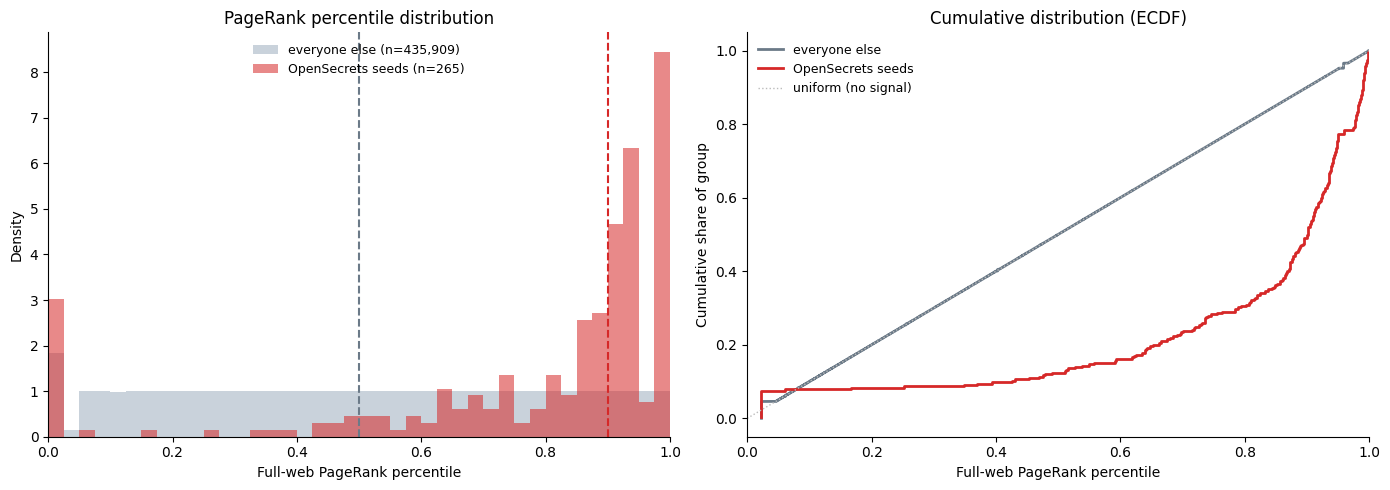

Median PageRank percentile: seeds 0.901 vs everyone else 0.500
Share landing in the top 10% of the web by PageRank: seeds 50.6% vs everyone else 10.0%


In [ ]:
# Distribution of full-web PageRank percentiles: known dark-money seeds vs. everyone else.
import matplotlib.pyplot as plt
import numpy as np

seed_pct = rank.loc[rank.is_seed == 1, "pr_pctile"].dropna().to_numpy()
rest_pct = rank.loc[rank.is_seed == 0, "pr_pctile"].dropna().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 41)
axes[0].hist(rest_pct, bins=bins, density=True, color="#B8C4D0", alpha=0.75,
             label=f"everyone else (n={len(rest_pct):,})")
axes[0].hist(seed_pct, bins=bins, density=True, color="#D62828", alpha=0.55,
             label=f"OpenSecrets seeds (n={len(seed_pct):,})")
axes[0].axvline(np.median(rest_pct), color="#6B7A88", linestyle="--", linewidth=1.5)
axes[0].axvline(np.median(seed_pct), color="#D62828", linestyle="--", linewidth=1.5)
axes[0].set_title("PageRank percentile distribution")
axes[0].set_xlabel("Full-web PageRank percentile")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=9, loc="upper center")

# ECDF makes the seeds' rightward shift explicit; the diagonal is what a uniform (no-signal) set would give.
for values, color, label in [(rest_pct, "#6B7A88", "everyone else"),
                             (seed_pct, "#D62828", "OpenSecrets seeds")]:
    xs = np.sort(values)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    axes[1].step(xs, ys, where="post", color=color, linewidth=2, label=label)
axes[1].plot([0, 1], [0, 1], color="#BBBBBB", linestyle=":", linewidth=1, label="uniform (no signal)")
axes[1].set_title("Cumulative distribution (ECDF)")
axes[1].set_xlabel("Full-web PageRank percentile")
axes[1].set_ylabel("Cumulative share of group")
axes[1].legend(frameon=False, fontsize=9, loc="upper left")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.set_xlim(0, 1)

fig.tight_layout()
plt.show()

print(f"Median PageRank percentile: seeds {np.median(seed_pct):.3f} vs everyone else {np.median(rest_pct):.3f}")
print(f"Share landing in the top 10% of the web by PageRank: "
      f"seeds {(seed_pct >= 0.90).mean():.1%} vs everyone else {(rest_pct >= 0.90).mean():.1%}")


## Narrowing the field before we model

Our first instinct was to score all 436,000 organizations, and it backfired. The model handed high marks to hospitals, universities, and seminaries, just because large institutions move money in ways that look a little like a conduit. Scoring that far outside what the model had learned wasn't trustworthy.

So we split the difference. The structural measures (degree, dollars in and out, global PageRank) still come from the full web, because a node's position only means something in the whole graph. But the candidate pool shrinks to the known dark-money groups plus everyone within one grant hop of them. Those neighbors are the hard negatives. They are close enough to be genuinely confusable, which is what makes them a fair test.

The model weighs four kinds of evidence: where an organization sits structurally, how it behaves with its money and legal status, how political its funding neighbors are, and how close it lands to the other known seeds (computed without ever letting an org see its own label). We report cross-validated AUC next to the train-test gap, then rank the unlabeled organizations by their out-of-fold probability.


In [ ]:
# Model on the seed-connected money neighborhood within the full web; full-web features + leak-free LOO-PPR proximity.
import numpy as np, pandas as pd, networkx as nx
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
GBC = lambda: GradientBoostingClassifier(random_state=42)

# Candidate pool = seeds + their 1-hop grant partners within the FULL web (hard negatives).
pool = {n for n in G.nodes if n in seed_set}
for s in list(pool):
    pool |= set(G.predecessors(s)) | set(G.successors(s))
Gp = G.subgraph(pool).copy()
nodes = list(Gp.nodes)
node_ix = {n: i for i, n in enumerate(nodes)}
y = np.array([1 if n in seed_set else 0 for n in nodes], dtype=int)

# --- structural features computed over the ENTIRE web (degree, dollars, global PageRank) ---
S = pd.DataFrame({"ein": nodes})
S["in_deg"]  = S.ein.map(dict(G.in_degree()));  S["out_deg"] = S.ein.map(dict(G.out_degree()))
din  = S.ein.map(dict(G.in_degree(weight="amt"))).values
dout = S.ein.map(dict(G.out_degree(weight="amt"))).values
S["log_d_in"] = np.log1p(din); S["log_d_out"] = np.log1p(dout)
S["conduit"] = np.where((din > 0) & (dout > 0), np.minimum(din, dout) / np.maximum(np.maximum(din, dout), 1), 0.0)
S["deg"] = S.in_deg + S.out_deg
S["global_pr"] = S.ein.map(pr)

# --- behaviour features for the pool (fy scopes every source to the same YEARS window as the graph) ---
# is_527: Schedule C line 5 lists section-527 orgs a filer paid, but filers mis-enter 501(c) orgs there.
# A real 527 files Form 8871/8872, not a 990, so exclude any named EIN that appears as a 990 filer.
# Exemption subsection is kept as flags (c3/c4/c5/c6 + an explicit "other") rather than dropping non-c3456
# orgs, which would also discard orgs with a missing type -- including several known seeds.
conn.register("g_nodes", pd.DataFrame({"ein": nodes}))
behav = q(f"""
WITH e AS (SELECT DISTINCT ein FROM g_nodes),
     fy AS (SELECT filing_id, ein, exempt_organization_type
            FROM irs990_filings
            WHERE TRY_CAST(tax_year AS INT) IN {YEARS}),
     rec AS (SELECT g.grantee_ein AS ein, SUM(TRY_CAST(g.amount AS DOUBLE)) received
             FROM irs990_filing_grants g JOIN fy USING (filing_id)
             WHERE g.grantee_ein IN (SELECT ein FROM e) GROUP BY g.grantee_ein),
     go AS (SELECT fy.ein, SUM(TRY_CAST(g.amount AS DOUBLE)) granted_out
            FROM fy JOIN irs990_filing_grants g USING (filing_id)
            WHERE fy.ein IN (SELECT ein FROM e) GROUP BY fy.ein),
     lob AS (SELECT DISTINCT fy.ein FROM fy JOIN irs990_filing_lobbying l USING (filing_id)
             WHERE fy.ein IN (SELECT ein FROM e)),
     p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
              WHERE ein IN (SELECT ein FROM e)
                AND ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL)),
     eot AS (SELECT ein, mode(exempt_organization_type) AS et FROM fy
             WHERE ein IN (SELECT ein FROM e) AND exempt_organization_type IS NOT NULL GROUP BY ein)
SELECT e.ein, o.current_name AS name,
       COALESCE(rec.received,0) AS received, COALESCE(go.granted_out,0) AS granted_out,
       CASE WHEN lob.ein  IS NOT NULL THEN 1 ELSE 0 END AS has_lobbying,
       CASE WHEN p527.ein IS NOT NULL THEN 1 ELSE 0 END AS is_527,
       CASE WHEN eot.et = '501(c)(3)' THEN 1 ELSE 0 END AS eot_c3,
       CASE WHEN eot.et = '501(c)(4)' THEN 1 ELSE 0 END AS eot_c4,
       CASE WHEN eot.et = '501(c)(5)' THEN 1 ELSE 0 END AS eot_c5,
       CASE WHEN eot.et = '501(c)(6)' THEN 1 ELSE 0 END AS eot_c6,
       CASE WHEN eot.et IS NOT NULL
             AND eot.et NOT IN ('501(c)(3)', '501(c)(4)', '501(c)(5)', '501(c)(6)')
            THEN 1 ELSE 0 END AS eot_c_other
FROM e LEFT JOIN organizations o ON o.ein = e.ein
LEFT JOIN rec ON rec.ein = e.ein LEFT JOIN go ON go.ein = e.ein
LEFT JOIN lob ON lob.ein = e.ein LEFT JOIN p527 ON p527.ein = e.ein LEFT JOIN eot ON eot.ein = e.ein
""")
M = S.merge(behav, on="ein", how="left")
M["name"] = M.name.fillna(M.ein.map(lambda e: crp_name.get(e) or org_name.get(e) or e))
M["log_received"] = np.log1p(M.received); M["log_granted_out"] = np.log1p(M.granted_out)
M["pass_through"] = np.where((M.received > 0) & (M.granted_out > 0),
                             np.minimum(M.received.values, M.granted_out.values)
                             / np.maximum(np.maximum(M.received.values, M.granted_out.values), 1), 0.0)
M["velocity"]  = M.granted_out / (M.received + 1.0)
M["name_flag"] = M.name.fillna("").str.upper().str.contains(
    r"ACTION|\bFUND\b|PROJECT|ALLIANCE|NETWORK|VOTERS|FREEDOM|PROSPERITY").astype(int)

# political-neighbor feature: share of grant partners that are c4/c6/527 (IRS attributes, seeds removed -> leak-free)
# Same 527 correction: drop named 527-recipients that are actually 990 filers (mis-entered 501(c) orgs).
pol_set = set(q("""
    WITH c46 AS (SELECT DISTINCT ein FROM irs990_filings
                 WHERE exempt_organization_type IN ('501(c)(4)', '501(c)(6)','501(c)(5)')
                 And political_activity_flag = 1),
         p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
                  WHERE ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL))
    SELECT ein FROM c46 UNION SELECT ein FROM p527
""").ein) - seed_set
def _pol_feats(n):
    succ = list(G.successors(n)); pred = list(G.predecessors(n))
    po = sum(1 for x in succ if x in pol_set); pi = sum(1 for x in pred if x in pol_set)
    return (po / len(succ) if succ else 0.0, pi / len(pred) if pred else 0.0, float(po + pi))
_pf = np.array([_pol_feats(n) for n in nodes])
M["pol_out_share"], M["pol_in_share"], M["pol_deg"] = _pf[:, 0], _pf[:, 1], _pf[:, 2]

STRUCTB = ["in_deg", "out_deg", "log_d_in", "log_d_out", "conduit", "deg", "global_pr"]
BEHAVB  = ["log_received", "log_granted_out", "pass_through", "velocity", "has_lobbying", "is_527",
           "name_flag", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
POL     = ["pol_out_share", "pol_in_share", "pol_deg"]
Xbase = M[STRUCTB + BEHAVB + POL].fillna(0).values

# --- single-source PPR from each seed on the pool graph, for leak-free LOO proximity ---
seeds_present = [n for n in nodes if n in seed_set]
Pmat = {}
for s in seeds_present:
    p = nx.pagerank(Gp, alpha=0.85, personalization={s: 1.0}, weight="amt", max_iter=500)
    Pmat[s] = np.array([p[n] for n in nodes])
diag = {s: Pmat[s][node_ix[s]] for s in seeds_present}

def prox(train_pos):   # proximity to OTHER seeds (leave-one-out): leak-free, symmetric for train & test
    a = np.zeros(len(nodes))
    for s in train_pos:
        a += Pmat[s]
    for s in train_pos:
        a[node_ix[s]] -= diag[s]
    return a

cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof_base, oof_prox = np.zeros(len(nodes)), np.zeros(len(nodes))
for tr, te in cv.split(Xbase, y):
    tp = [nodes[i] for i in tr if y[i] == 1]
    Xp = np.column_stack([Xbase, prox(tp)])
    oof_base[te] = GBC().fit(Xbase[tr], y[tr]).predict_proba(Xbase[te])[:, 1]
    oof_prox[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]

print(f"full web {G.number_of_nodes():,} orgs  |  candidate pool {len(nodes):,} "
      f"(seeds {int(y.sum())} + hard negatives {int((y==0).sum()):,})")
print(f"{'model':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, oof in [("structural + behaviour + political", oof_base), ("+ leave-one-out PPR proximity", oof_prox)]:
    print(f"{tag:34s} {roc_auc_score(y, oof):>11.3f} {average_precision_score(y, oof):>10.3f}")

tr, te = train_test_split(np.arange(len(nodes)), test_size=0.30, stratify=y, random_state=42)
Xp = np.column_stack([Xbase, prox([nodes[i] for i in tr if y[i] == 1])])
mdl = GBC().fit(Xp[tr], y[tr])
gtr = roc_auc_score(y[tr], mdl.predict_proba(Xp[tr])[:, 1]); gte = roc_auc_score(y[te], mdl.predict_proba(Xp[te])[:, 1])
print(f"held-out (LOO-PPR)  train {gtr:.3f}  test {gte:.3f}  gap {gtr - gte:.3f}")

M["score"] = oof_prox
M["is_seed"] = y
leads = M[M.is_seed == 0].sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):")
display(leads.head(25)[["ein", "name", "score", "pol_out_share", "pol_in_share", "received", "granted_out",
                        "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]])

full web 436,174 orgs  |  candidate pool 3,045 (seeds 240 + hard negatives 2,805)
model                              OOF ROC-AUC OOF PR-AUC
structural + behaviour + political       0.845      0.312
+ leave-one-out PPR proximity            0.853      0.329
held-out (LOO-PPR)  train 0.972  test 0.853  gap 0.119

Top 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):


,ein,name,score,pol_out_share,pol_in_share,received,granted_out,has_lobbying,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other
0,923566420,Smarter Regulation,0.957959,0.000000,1.000000,110000.0,100000.0,0,0,0,1,0,0,0
1,812956944,SAVING TEXAS,0.954077,0.500000,0.000000,741745.0,2100000.0,1,0,0,1,0,0,0
2,020226432,NEA - NEW HAMPSHIRE,0.927460,0.000000,1.000000,1631125.0,25000.0,1,0,0,0,0,1,0
3,264568349,America Votes,0.867674,0.534884,0.685185,185941769.0,202548323.0,1,0,0,1,0,0,0
4,463083014,POPULATION CONNECTION ACTION FUND,0.757118,0.000000,0.000000,4800000.0,7500.0,0,0,0,1,0,0,0
5,270637437,BOLD ALLIANCE INC,0.717296,0.000000,1.000000,125000.0,65750.0,1,0,0,1,0,0,0
6,873854090,Secure Democracy USA,0.688002,1.000000,0.500000,3092000.0,94750.0,1,0,0,1,0,0,0
7,834660479,RURAL ARIZONA ACTION,0.671930,0.500000,0.705882,3102000.0,700000.0,1,0,0,1,0,0,0
8,921057815,MAGA ACTION INC,0.658566,0.500000,1.000000,275000.0,10843148.0,0,0,0,1,0,0,0
9,844552289,CENTER ACTION NOW,0.644476,0.500000,0.000000,0.0,110000.0,0,0,0,1,0,0,0


### Deep dive: the political-neighbor feature (`pol_out_share`, `pol_in_share`, `pol_deg`)

The money features ask *"does this org move money like a conduit?"* This one asks a different question: *"does this org keep political company?"* Some real dark-money vehicles — trade-association leagues, chambers, credit-union leagues — don't show the pass-through money pattern at all, so `conduit`/`pass_through`/`velocity` go blind on them. But they sit **surrounded by** the tax types that are legally built for politics. This feature is the backstop that catches that "guilt by association."

**Why these tax types are the "political" set.** The dark-money hypothesis is money flowing through orgs that *can do politics without naming donors*. The IRS subsection is the cleanest signal of that permission:

- **501(c)(4)** — "social welfare," can spend heavily on politics without disclosing donors (the classic vehicle),
- **501(c)(5)** / **501(c)(6)** — labor and trade/business leagues, same political latitude,
- **527** — exists only to influence elections.

The contrast is **501(c)(3)**: charities, universities, hospitals, donor-advised funds — legally barred from partisan work, so a (c)(3)-heavy neighborhood points the *other* way.

**Building `pol_set`.** `c46` gathers every (c)(4)/(c)(5)/(c)(6) EIN; `p527` gathers 527 EINs but drops any that also filed a 990 (the "527 correction" — filers mis-enter ordinary 501(c) orgs on the 527 schedule, and a real 527 files Form 8871/8872, not a 990). The two are `UNION`ed, then **`- seed_set`** removes the known dark-money seeds. That last step is what makes the feature **leak-free**: if seeds counted as political neighbors, an org would score high just for touching a seed — leaking the very label we're predicting. Stripping them leaves a signal built from **IRS tax attributes only**.

**The match.** For each org `n`, its grant partners come straight from the graph — `succ = G.successors(n)` (who it funds) and `pred = G.predecessors(n)` (who funds it). The mechanic is an **exact EIN set-membership test**, `x in pol_set` (O(1) on a `set`): count how many partners on each side are political.

**The three features:**

| feature | formula | meaning |
|---|---|---|
| `pol_out_share` | political grantees ÷ all grantees | how concentrated its *funding out* is in political vehicles |
| `pol_in_share` | political funders ÷ all funders | how concentrated its *funding in* is |
| `pol_deg` | political grantees + funders (count) | raw number of political partners |

Shares say *how concentrated* the political ties are; `pol_deg` separates a tiny org with one political partner from a hub wired to dozens.

**Worked example.** Suppose `pol_set = {111111111, 222222222, 333333333}` and org **X** has:

- grantees `succ = [111111111, 444444444, 222222222]` → 2 of 3 political → `pol_out_share = 2/3 = 0.67`
- funders `pred = [333333333, 555555555]` → 1 of 2 political → `pol_in_share = 1/2 = 0.50`
- `pol_deg = 2 + 1 = 3`

A hospital **Y** that only grants to other hospitals matches nothing → `0.0, 0.0, 0` on all three, pushing its dark-money likelihood down. That contrast — X wired into political vehicles, Y not — is exactly the signal.

**Why keep it.** The "Does the political-neighbour feature help?" ablation below runs the model with and without this block on both out-of-fold and held-out seeds; it earns its place by lifting recall on the trade-group-style dark money the money features can't catch, without leaking the label.


### What tax status tells us

Before we look at any dollars, an organization's exemption subsection already says something about what it is for, which makes it a useful and almost leak-free prior. Across the pool, comparing the share of each group that carries the flag (and the seed-versus-negative lift):

- 501(c)(4): 79% of the known dark-money groups against 19% of the hard negatives, about four times as often. These "social welfare" groups can spend heavily on politics without naming donors. This is the strongest single flag.
- 527: 28% versus 9%, about three times as often. These exist to influence elections.
- 501(c)(6): 11% versus 13%, basically even. Trade associations show up on both sides, so this flag only helps together with lobbying and pass-through behaviour.
- 501(c)(3): 8% of seeds versus 46% of negatives, about 0.17x. Charities, universities, and donor-advised funds cannot do partisan work, so this flag pushes the score down.

None of these settle anything alone. They are priors about the type of organization, and the network and behaviour signals still do the real work. The cell below shows the numbers and a few examples from each side.


In [ ]:
# Showcase the exemption-subsection contrast: dark-money seeds vs. non-dark-money hard negatives.
flags = ["is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
seed_rates = M.loc[y == 1, flags].mean()
neg_rates  = M.loc[y == 0, flags].mean()
profile = pd.DataFrame({
    "dark money (seed) %": (seed_rates * 100).round(1),
    "not dark money (neg) %": (neg_rates * 100).round(1),
    "lift (seed / neg)": (seed_rates / neg_rates.replace(0, np.nan)).round(2),
})
print(f"Exemption profile across {int((y==1).sum())} seeds vs {int((y==0).sum()):,} hard negatives:")
display(profile)

cols = ["ein", "name", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other", "has_lobbying", "score"]
print("\nDark-money examples (seeds carrying a c4/c6/527 political vehicle flag):")
display(M[(y == 1) & (M[["is_527", "eot_c4", "eot_c6"]].sum(axis=1) > 0)]
        .sort_values("score", ascending=False)[cols].head(10).reset_index(drop=True))

print("\nNon-dark-money examples (hard-negative c3 charities, the flag that pushes score down):")
display(M[(y == 0) & (M.eot_c3 == 1)]
        .sort_values("received", ascending=False)[cols].head(10).reset_index(drop=True))


Exemption profile across 265 seeds vs 4,156 hard negatives:


,dark money (seed) %,not dark money (neg) %,lift (seed / neg)
is_527,0.0,4.4,0.00
eot_c3,7.5,45.8,0.16
eot_c4,77.0,18.9,4.07
eot_c5,1.1,1.0,1.15
eot_c6,10.9,12.4,0.88
eot_c_other,0.8,0.4,1.85



Dark-money examples (seeds carrying a c4/c6/527 political vehicle flag):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,541564919,THE 60 PLUS ASSOCIATION INC,0,0,1,0,0,0,0,0.958901
1,352317275,IMMIGRANTS' LIST CIVIC ACTION,0,0,1,0,0,0,1,0.929482
2,262731617,AMERICAN ENERGY ALLIANCE,0,0,1,0,0,0,0,0.929295
3,993614737,Independent Veterans of America Action,0,0,1,0,0,0,1,0.923079
4,361520690,National Association of Realtors,0,0,0,0,1,0,1,0.922146
5,474435527,Black Youth Project 100 NFP,0,0,1,0,0,0,1,0.893784
6,261728410,CARE ACTION NOW INCORPORATED,0,0,1,0,0,0,1,0.881933
7,770053480,CIVIC EMPOWERMENT COALITION,0,0,1,0,0,0,1,0.869596
8,651218474,POWERPAC ORG,0,0,1,0,0,0,1,0.858734
9,831769970,NEW AMERICAN LEADERS ACTION FUND INC,0,0,1,0,0,0,1,0.852955



Non-dark-money examples (hard-negative c3 charities, the flag that pushes score down):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,416011702,MAYO CLINIC,0,1,0,0,0,0,1,0.008460
1,560532129,DUKE UNIVERSITY,0,1,0,0,0,0,1,0.026498
2,237825575,NATIONAL PHILANTHROPIC TRUST,0,1,0,0,0,0,1,0.007098
3,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,0,1,0,0,0,0,1,0.008538
4,135562308,New York University,0,1,0,0,0,0,1,0.008018
5,520595110,JOHNS HOPKINS UNIVERSITY,0,1,0,0,0,0,1,0.011327
6,311640316,DONOR ADVISED CHARITABLE GIVING INC,0,1,0,0,0,0,1,0.007747
7,941156365,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,1,0,0,0,0,1,0.007531
8,581493949,NATL CHRISTIAN CHARITABLE FDN INC,0,1,0,0,0,0,0,0.007837
9,205205488,Silicon Valley Community Foundation,0,1,0,0,0,0,1,0.006405


## From model score to a shortlist

A high score means one thing: this organization moves money like the ones we already know. It does not mean the organization is political. Left alone, the ranking pushes up big institutions that just have unusual finances.

So before a name goes on a shortlist, we ask for a second reason to keep it. We count five signs of political relevance: reported lobbying, 527 status, (c)(4) status, (c)(6) status, and having at least a quarter of its grant partners be political organizations. If we require two of the five, most of the institutional noise drops out and we keep almost all of the known labels.

The table tries one, two, and three signals so you can see the trade-off between keeping real labels and dropping hard negatives. Two worked best. This is a filter applied after scoring, so it does not change the model or the scores.


In [ ]:
# Post-model eligibility screen intended to reduce obvious institutional false positives.
POLITICAL_NEIGHBOR_MIN = 0.25
MIN_ELIGIBILITY_SIGNALS = 2

eligibility_signals = pd.DataFrame({
    "reported_lobbying": M["has_lobbying"].eq(1),
    "section_527": M["is_527"].eq(1),
    "section_c4": M["eot_c4"].eq(1),
    "section_c6": M["eot_c6"].eq(1),
    "political_funding_neighbors": (
        M["pol_out_share"].ge(POLITICAL_NEIGHBOR_MIN)
        | M["pol_in_share"].ge(POLITICAL_NEIGHBOR_MIN)
    ),
})
M["eligibility_signal_count"] = eligibility_signals.sum(axis=1)
M["eligible_review"] = M["eligibility_signal_count"].ge(MIN_ELIGIBILITY_SIGNALS)

seed_mask = M["is_seed"].eq(1)
negative_mask = ~seed_mask
sensitivity_rows = []
for minimum_signals in (1, 2, 3):
    threshold_mask = M["eligibility_signal_count"].ge(minimum_signals)
    sensitivity_rows.append({
        "minimum_signals": minimum_signals,
        "known_labels_retained": int((threshold_mask & seed_mask).sum()),
        "known_label_retention": threshold_mask[seed_mask].mean(),
        "hard_negatives_retained": int((threshold_mask & negative_mask).sum()),
        "hard_negative_reduction": 1 - threshold_mask[negative_mask].mean(),
        "original_top25_retained": int(
            leads.head(25)["ein"].isin(M.loc[threshold_mask, "ein"]).sum()
        ),
    })
screen_sensitivity = pd.DataFrame(sensitivity_rows)

seed_retention = M.loc[seed_mask, "eligible_review"].mean()
negative_reduction = 1 - M.loc[negative_mask, "eligible_review"].mean()
top25_before = leads.head(25).copy()
top25_after = top25_before.merge(
    M[["ein", "eligible_review", "eligibility_signal_count"]],
    on="ein",
    how="left",
)
filtered_leads = (
    M.loc[(M["is_seed"] == 0) & M["eligible_review"]]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
excluded_top25 = top25_after.loc[~top25_after["eligible_review"]]

print(f"Selected rule: at least {MIN_ELIGIBILITY_SIGNALS} independent signals")
print(f"Known-label retention: {seed_retention:.1%}")
print(f"Hard-negative reduction: {negative_reduction:.1%}")
print(
    f"Original top 25 retained: {int(top25_after.eligible_review.sum())}/25; "
    f"excluded: {len(excluded_top25)}"
)
display(screen_sensitivity.style.format({
    "known_labels_retained": "{:,.0f}",
    "known_label_retention": "{:.1%}",
    "hard_negatives_retained": "{:,.0f}",
    "hard_negative_reduction": "{:.1%}",
    "original_top25_retained": "{:,.0f}",
}))

print("\nExcluded from the original top 25:")
display(excluded_top25[["ein", "name", "score", "eligibility_signal_count"]])

print("\nTop 25 after the political-relevance screen:")
display(filtered_leads.head(25)[[
    "ein", "name", "score", "eligibility_signal_count",
    "has_lobbying", "is_527", "eot_c4", "eot_c6","eot_c3", "eot_c5", "eot_c_other",
    "pol_out_share", "pol_in_share",
]])

Selected rule: at least 2 independent signals
Known-label retention: 87.2%
Hard-negative reduction: 68.2%
Original top 25 retained: 23/25; excluded: 2


,minimum_signals,known_labels_retained,known_label_retention,hard_negatives_retained,hard_negative_reduction,original_top25_retained
0,1,257,97.0%,"2,589",37.7%,25
1,2,231,87.2%,"1,322",68.2%,23
2,3,167,63.0%,551,86.7%,12



Excluded from the original top 25:


,ein,name,score,eligibility_signal_count
2,530167933,THE WILDERNESS SOCIETY,0.831783,1
10,462083021,TRANSPORTATION ENERGY INSTITUTE,0.634742,1



Top 25 after the political-relevance screen:


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,eot_c3,eot_c5,eot_c_other,pol_out_share,pol_in_share
0,391142477,WISCONSIN LABORERS' DISTRICT COUNCIL,0.856983,2,1,0,0,0,0,1,0,0.750000,1.000000
1,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.840749,3,1,0,1,0,0,0,0,0.000000,1.000000
2,270637437,BOLD ALLIANCE INC,0.830964,3,1,0,1,0,0,0,0,0.000000,1.000000
3,934932914,Defend Washington,0.788846,2,0,0,1,0,0,0,0,0.000000,0.900000
4,742736849,TEXAS FREEDOM NETWORK,0.736980,3,1,0,1,0,0,0,0,1.000000,0.769231
5,520941402,THE ROAD INFORMATION PROGRAM INC,0.731327,2,0,0,0,1,0,0,0,0.000000,0.875000
6,861965600,BLACK MEN VOTE CIVIC ACTION FUND,0.688065,2,0,0,1,0,0,0,0,0.000000,0.888889
7,923566420,Smarter Regulation,0.673797,2,0,0,1,0,0,0,0,0.000000,1.000000
8,834660479,RURAL ARIZONA ACTION,0.653091,3,1,0,1,0,0,0,0,1.000000,0.705882
9,920652730,Global Impact Social Welfare Fund,0.633803,3,1,0,1,0,0,0,0,0.653061,0.571429


In [ ]:
# Confusion matrices use leak-free out-of-fold scores at a fixed 0.50 threshold.
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CLASSIFICATION_THRESHOLD = 0.50
base_prediction = oof_prox >= CLASSIFICATION_THRESHOLD
screened_prediction = base_prediction & M["eligible_review"].to_numpy()

confusion_rows = []
for label, prediction in [
    ("Model only", base_prediction),
    ("Model + two-signal screen", screened_prediction),
]:
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        y, prediction, labels=[0, 1]
    ).ravel()
    confusion_rows.append({
        "method": label,
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive,
        "precision": precision_score(y, prediction, zero_division=0),
        "recall": recall_score(y, prediction, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "false_positive_rate": false_positive / (true_negative + false_positive),
    })

confusion_results = pd.DataFrame(confusion_rows).set_index("method")
print(f"OOF classification threshold: {CLASSIFICATION_THRESHOLD:.2f}")
display(confusion_results.style.format({
    "true_negative": "{:,.0f}",
    "false_positive": "{:,.0f}",
    "false_negative": "{:,.0f}",
    "true_positive": "{:,.0f}",
    "precision": "{:.1%}",
    "recall": "{:.1%}",
    "specificity": "{:.1%}",
    "false_positive_rate": "{:.1%}",
}))

OOF classification threshold: 0.50


,true_negative,false_positive,false_negative,true_positive,precision,recall,specificity,false_positive_rate
method,,,,,,,,
Model only,"4,128",28,222,43,60.6%,16.2%,99.3%,0.7%
Model + two-signal screen,"4,130",26,223,42,61.8%,15.8%,99.4%,0.6%


## Checking against the transparency index

We also compare against an outside measure. The transparency index scores how much each organization discloses. We join it by EIN, keep the most recent filing per organization, and line up the known dark-money groups against the rest of the pool on coverage, score, and how complete the filings are.

Then we ask whether transparency adds anything the model did not already capture. A short ablation answers that. We treat the index as one more piece of evidence, not a verdict. A low score is a reason to look closer, not proof of anything.


In [ ]:
# Latest transparency record per EIN within the IRS analysis years.
conn.execute(f"""
CREATE OR REPLACE VIEW transparency_index AS
SELECT *
FROM read_parquet(
    '{PARQUET_BASE}/transparency_index/transparency_index__*.parquet',
    union_by_name=true
)
""")

transparency = q(f"""
WITH ranked AS (
    SELECT
        ein,
        tax_year,
        filer_name,
        normalized_index_score,
        observed_components,
        complete,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY tax_year DESC, filing_id DESC
        ) AS recency
    FROM transparency_index
    WHERE tax_year IN {YEARS}
)
SELECT * EXCLUDE recency
FROM ranked
WHERE recency = 1
""")

transparency_pool = (
    M[["ein", "name"]]
    .merge(transparency, on="ein", how="left")
    .assign(
        is_opensecrets=y,
        has_transparency=lambda frame: frame.normalized_index_score.notna().astype(int),
    )
)

transparency_summary = (
    transparency_pool.groupby("is_opensecrets")
    .agg(
        organizations=("ein", "size"),
        covered=("has_transparency", "sum"),
        coverage_rate=("has_transparency", "mean"),
        median_index_score=("normalized_index_score", "median"),
        mean_index_score=("normalized_index_score", "mean"),
        median_components=("observed_components", "median"),
        complete_rate=("complete", "mean"),
    )
    .rename(index={0: "other candidates", 1: "OpenSecrets"})
)

display(
    transparency_summary.style.format({
        "organizations": "{:,.0f}",
        "covered": "{:,.0f}",
        "coverage_rate": "{:.1%}",
        "median_index_score": "{:.3f}",
        "mean_index_score": "{:.3f}",
        "median_components": "{:.1f}",
        "complete_rate": "{:.1%}",
    })
)

# Missing records receive neutral values plus an explicit coverage indicator.
transparency_features = pd.DataFrame({
    "has_transparency": transparency_pool.has_transparency,
    "transparency_score": transparency_pool.normalized_index_score.fillna(
        transparency_pool.normalized_index_score.median()
    ),
    "transparency_components": transparency_pool.observed_components.fillna(0),
    "transparency_complete": transparency_pool.complete.fillna(0),
})
Xtransparency = np.column_stack([Xbase, transparency_features.values])

transparency_oof = {}
cv_transparency = StratifiedKFold(5, shuffle=True, random_state=42)
for label, feature_matrix in [
    ("full model", Xbase),
    ("full model + transparency", Xtransparency),
]:
    predictions = np.zeros(len(nodes))
    for train_rows, test_rows in cv_transparency.split(feature_matrix, y):
        training_seeds = [nodes[index] for index in train_rows if y[index] == 1]
        fold_matrix = np.column_stack([feature_matrix, prox(training_seeds)])
        predictions[test_rows] = GBC().fit(
            fold_matrix[train_rows], y[train_rows]
        ).predict_proba(fold_matrix[test_rows])[:, 1]
    transparency_oof[label] = predictions

print(f"{'feature set':30s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for label, predictions in transparency_oof.items():
    print(
        f"{label:30s} "
        f"{roc_auc_score(y, predictions):>11.3f} "
        f"{average_precision_score(y, predictions):>10.3f}"
    )

,organizations,covered,coverage_rate,median_index_score,mean_index_score,median_components,complete_rate
is_opensecrets,,,,,,,
other candidates,"4,156",787,18.9%,5.594,5.525,9.0,86.0%
OpenSecrets,265,204,77.0%,5.565,5.576,9.0,88.7%


feature set                    OOF ROC-AUC OOF PR-AUC
full model                           0.887      0.382
full model + transparency            0.886      0.356


In [ ]:
# Transparency review for unlabeled organizations classified as positive at the 0.50 threshold.
fp_transparency = transparency.copy()
fp_transparency["index_percentile"] = fp_transparency["normalized_index_score"].rank(pct=True)

review_columns = [
    "ein", "name", "score", "eligibility_signal_count",
    "has_lobbying", "is_527", "eot_c4", "eot_c6",
]
remaining_fp_mask = (y == 0) & screened_prediction
removed_fp_mask = (y == 0) & base_prediction & ~screened_prediction

transparency_cols = [
    "ein", "tax_year", "normalized_index_score", "index_percentile",
    "observed_components", "complete",
]
remaining_fp_transparency = (
    M.loc[remaining_fp_mask, review_columns]
    .merge(fp_transparency[transparency_cols], on="ein", how="left")
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
removed_fp_transparency = (
    M.loc[removed_fp_mask, review_columns]
    .merge(fp_transparency[transparency_cols], on="ein", how="left")
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

transparency_fmt = {
    "score": "{:.3f}",
    "tax_year": "{:.0f}",
    "normalized_index_score": "{:.3f}",
    "index_percentile": "{:.1%}",
    "observed_components": "{:.0f}",
    "complete": "{:.0f}",
}

covered_remaining_fp = remaining_fp_transparency["normalized_index_score"].notna()
print(
    f"Transparency coverage for remaining screened false positives: "
    f"{covered_remaining_fp.sum()}/{len(remaining_fp_transparency)} "
    f"({covered_remaining_fp.mean():.1%})"
)
if covered_remaining_fp.any():
    print(
        "Index score among covered records: "
        f"median {remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].median():.3f}; "
        f"range {remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].min():.3f}-"
        f"{remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].max():.3f}"
    )

display(remaining_fp_transparency.style.format(transparency_fmt, na_rep="Not available"))

# At the strict 0.50 cutoff the model's own positives almost always carry >=2 political
# signals, so the screen removes none of them; it earns its keep further down the ranking.
removed_count = int(removed_fp_mask.sum())
if removed_count:
    print(f"\nModel false positives removed by the two-signal screen ({removed_count}):")
    display(removed_fp_transparency.style.format(transparency_fmt, na_rep="Not available"))
else:
    print("\nModel false positives removed by the two-signal screen: none at the 0.50 cutoff.")
    print("The model rarely scores an apolitical org above 0.50, so its high-confidence false")
    print("positives already clear two political signals. The screen instead trims lower-ranked leads:")
    ranked_negatives = M.loc[M.is_seed == 0].sort_values("score", ascending=False)
    top_ranked_negatives = ranked_negatives.head(100)
    dropped_by_screen = top_ranked_negatives.loc[~top_ranked_negatives.eligible_review]
    print(f"Of the top 100 non-seed leads by score, {len(dropped_by_screen)} are dropped as ineligible (<2 signals).")
    display(
        dropped_by_screen[review_columns]
        .head(15)
        .reset_index(drop=True)
        .style.format({"score": "{:.3f}"})
    )


Transparency coverage for remaining screened false positives: 21/26 (80.8%)
Index score among covered records: median 5.804; range 3.568-8.292


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,tax_year,normalized_index_score,index_percentile,observed_components,complete
0,391142477,WISCONSIN LABORERS' DISTRICT COUNCIL,0.857,2,1,0,0,0,Not available,Not available,Not available,Not available,Not available
1,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.841,3,1,0,1,0,2024,5.319,60.2%,8,0
2,270637437,BOLD ALLIANCE INC,0.831,3,1,0,1,0,2024,6.162,92.1%,9,1
3,934932914,Defend Washington,0.789,2,0,0,1,0,2024,5.355,62.2%,8,0
4,742736849,TEXAS FREEDOM NETWORK,0.737,3,1,0,1,0,2024,3.568,3.2%,9,1
5,520941402,THE ROAD INFORMATION PROGRAM INC,0.731,2,0,0,0,1,Not available,Not available,Not available,Not available,Not available
6,861965600,BLACK MEN VOTE CIVIC ACTION FUND,0.688,2,0,0,1,0,2024,5.804,87.4%,9,1
7,923566420,Smarter Regulation,0.674,2,0,0,1,0,2023,6.911,98.5%,9,1
8,834660479,RURAL ARIZONA ACTION,0.653,3,1,0,1,0,2024,6.154,92.0%,9,1
9,920652730,Global Impact Social Welfare Fund,0.634,3,1,0,1,0,2024,6.901,98.4%,9,1



Model false positives removed by the two-signal screen (2):


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,tax_year,normalized_index_score,index_percentile,observed_components,complete
0,530167933,THE WILDERNESS SOCIETY,0.832,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available
1,462083021,TRANSPORTATION ENERGY INSTITUTE,0.635,1,0,0,1,0,2024,3.943,6.9%,9,1


In [ ]:
# Review transparency records for the highest-ranked non-seed model leads.
transparency_ranked = transparency.copy()
transparency_ranked["index_percentile"] = (
    transparency_ranked["normalized_index_score"].rank(pct=True)
)

model_lead_transparency = (
    leads.head(25)[["ein", "name", "score"]]
    .rename(columns={"score": "model_score"})
    .merge(
        transparency_ranked[[
            "ein",
            "tax_year",
            "normalized_index_score",
            "index_percentile",
            "observed_components",
            "complete",
        ]],
        on="ein",
        how="left",
    )
)
model_lead_transparency["has_transparency"] = (
    model_lead_transparency.normalized_index_score.notna()
)

covered_leads = int(model_lead_transparency.has_transparency.sum())
print(
    f"Transparency coverage for top 25 model leads: "
    f"{covered_leads}/25 ({covered_leads / 25:.1%})"
)

display(
    model_lead_transparency.style.format({
        "model_score": "{:.3f}",
        "tax_year": "{:.0f}",
        "normalized_index_score": "{:.3f}",
        "index_percentile": "{:.1%}",
        "observed_components": "{:.0f}",
        "complete": "{:.0f}",
    }, na_rep="Not available")
)

Transparency coverage for top 25 model leads: 19/25 (76.0%)


,ein,name,model_score,tax_year,normalized_index_score,index_percentile,observed_components,complete,has_transparency
0,391142477,WISCONSIN LABORERS' DISTRICT COUNCIL,0.857,Not available,Not available,Not available,Not available,Not available,False
1,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.841,2024,5.319,60.2%,8,0,True
2,530167933,THE WILDERNESS SOCIETY,0.832,Not available,Not available,Not available,Not available,Not available,False
3,270637437,BOLD ALLIANCE INC,0.831,2024,6.162,92.1%,9,1,True
4,934932914,Defend Washington,0.789,2024,5.355,62.2%,8,0,True
5,742736849,TEXAS FREEDOM NETWORK,0.737,2024,3.568,3.2%,9,1,True
6,520941402,THE ROAD INFORMATION PROGRAM INC,0.731,Not available,Not available,Not available,Not available,Not available,False
7,861965600,BLACK MEN VOTE CIVIC ACTION FUND,0.688,2024,5.804,87.4%,9,1,True
8,923566420,Smarter Regulation,0.674,2023,6.911,98.5%,9,1,True
9,834660479,RURAL ARIZONA ACTION,0.653,2024,6.154,92.0%,9,1,True


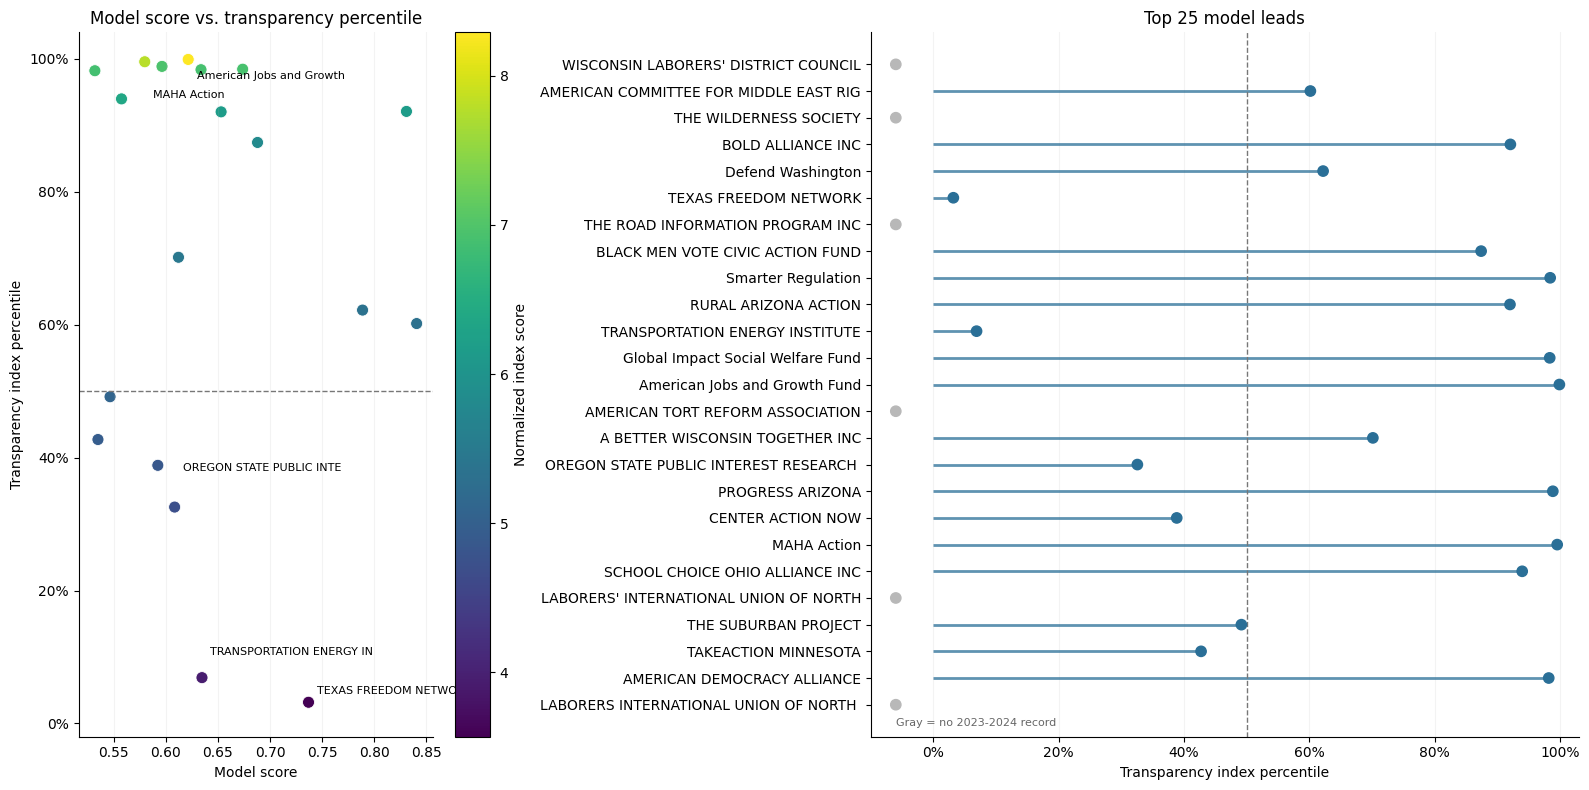

In [ ]:
# Visual comparison of model rank and transparency index position.
import matplotlib.pyplot as plt

covered = model_lead_transparency[model_lead_transparency.has_transparency].copy()
plot_leads = model_lead_transparency.copy()
plot_leads["lead_label"] = plot_leads["name"].str.slice(0, 38)
plot_leads["plot_percentile"] = plot_leads.index_percentile.fillna(-0.06)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.0, 1.6]},
)

scatter = axes[0].scatter(
    covered.model_score,
    covered.index_percentile,
    c=covered.normalized_index_score,
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.6,
)
axes[0].axhline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[0].set_title("Model score vs. transparency percentile")
axes[0].set_xlabel("Model score")
axes[0].set_ylabel("Transparency index percentile")
axes[0].set_ylim(-0.02, 1.04)
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

label_leads = pd.concat([
    covered.nlargest(2, "index_percentile"),
    covered.nsmallest(3, "index_percentile"),
]).drop_duplicates("ein")
high_index = 0
low_index = 0
for row in label_leads.itertuples(index=False):
    if row.index_percentile >= 0.5:
        offset = (6, -14 - high_index * 12)
        high_index += 1
    else:
        offset = (6, 6 + low_index * 10)
        low_index += 1
    axes[0].annotate(
        row.name[:24],
        (row.model_score, row.index_percentile),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
fig.colorbar(scatter, ax=axes[0], label="Normalized index score")

rank_positions = np.arange(len(plot_leads))
point_colors = np.where(plot_leads.has_transparency, "#2A6F97", "#B8B8B8")
axes[1].hlines(
    rank_positions,
    xmin=0,
    xmax=plot_leads.plot_percentile.clip(lower=0),
    color=point_colors,
    linewidth=2,
    alpha=0.75,
)
axes[1].scatter(
    plot_leads.plot_percentile,
    rank_positions,
    color=point_colors,
    s=55,
    zorder=3,
)
axes[1].axvline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[1].set_yticks(rank_positions, plot_leads.lead_label)
axes[1].invert_yaxis()
axes[1].set_xlim(-0.1, 1.03)
axes[1].set_xlabel("Transparency index percentile")
axes[1].set_title("Top 25 model leads")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].text(
    -0.06,
    len(plot_leads) - 0.2,
    "Gray = no 2023-2024 record",
    fontsize=8,
    color="#666666",
    ha="left",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="x", alpha=0.15)

fig.tight_layout()
plt.show()

## Seeing the connections

These two views show the shortlisted leads next to the known dark-money groups they grant to or receive from. The first covers the whole screened neighbourhood, and the second zooms in on the top few. Hover a node or an edge to see the grantor, the grantee, and the dollars between them.


In [ ]:
# Interactive (Plotly) version of the screened-leads-vs-labels grant network.
import plotly.graph_objects as go
import networkx as nx

# Rebuild the same subgraph as the static figure: top-20 screened (non-seed) leads
# plus only the known-label seeds they directly grant to or receive from.
_name = M.set_index("ein").name.to_dict()
_prob = M.set_index("ein").score.to_dict()
_label = lambda n: (_name.get(n) or nm(n))
_dollars_in = dict(G.in_degree(weight="amt"))
_dollars_out = dict(G.out_degree(weight="amt"))

_top = set(filtered_leads.head(20).ein)
_keep = set(_top)
for _lead in _top:
    _keep.update(n for n in G.predecessors(_lead) if n in seed_set)
    _keep.update(n for n in G.successors(_lead) if n in seed_set)
H = G.subgraph(_keep).copy()
H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])

pos = nx.spring_layout(H, k=0.9, seed=2, weight="amt")
amt = nx.get_edge_attributes(H, "amt")

# Edge lines, plus invisible midpoint markers naming grantor + grantee and grant $ on hover.
edge_x, edge_y, mid_x, mid_y, mid_txt = [], [], [], [], []
for u, v in H.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]
    mid_x.append((x0 + x1) / 2); mid_y.append((y0 + y1) / 2)
    mid_txt.append(
        f"<b>Grantor:</b> {_label(u)} (EIN {u})<br>"
        f"<b>Grantee:</b> {_label(v)} (EIN {v})<br>"
        f"<b>Grant:</b> ${amt.get((u, v), 0):,.0f}"
    )

edge_lines = go.Scatter(x=edge_x, y=edge_y, mode="lines",
                        line=dict(width=0.7, color="#CCCCCC"),
                        hoverinfo="none", showlegend=False)
edge_hover = go.Scatter(x=mid_x, y=mid_y, mode="markers",
                        marker=dict(size=8, color="rgba(0,0,0,0)"),
                        hoverinfo="text", text=mid_txt, showlegend=False)

def _rel_lines(n):
    # This node's direct grant partners inside the drawn subgraph, largest first.
    outs = sorted(((amt.get((n, w), 0.0), w) for w in H.successors(n)), reverse=True)[:5]
    ins = sorted(((amt.get((w, n), 0.0), w) for w in H.predecessors(n)), reverse=True)[:5]
    parts = []
    if outs:
        parts.append("<b>grants to:</b> " + "; ".join(f"{_label(w)} ${a:,.0f}" for a, w in outs))
    if ins:
        parts.append("<b>receives from:</b> " + "; ".join(f"{_label(w)} ${a:,.0f}" for a, w in ins))
    return "<br>".join(parts)

def _node_scatter(members, color, legend, sizer, show_text):
    hover = []
    for n in members:
        base = (f"<b>{_label(n)}</b><br>EIN {n}"
                f"<br>model score {_prob.get(n, float('nan')):.3f}"
                f"<br>$ received {_dollars_in.get(n, 0):,.0f}"
                f"<br>$ granted {_dollars_out.get(n, 0):,.0f}")
        rel = _rel_lines(n)
        hover.append(base + ("<br>" + rel if rel else ""))
    return go.Scatter(
        x=[pos[n][0] for n in members], y=[pos[n][1] for n in members],
        mode="markers+text" if show_text else "markers", name=legend,
        text=[_label(n)[:24] for n in members] if show_text else None,
        textposition="top center", textfont=dict(size=8),
        hovertext=hover, hoverinfo="text",
        marker=dict(color=color, size=[sizer(n) for n in members],
                    line=dict(width=0.6, color="white")),
    )

_seeds = [n for n in H.nodes if n in seed_set]
_leads = [n for n in H.nodes if n not in seed_set]

fig = go.Figure([
    edge_lines, edge_hover,
    _node_scatter(_seeds, "#D62828", "Known label (OpenSecrets)", lambda n: 16, False),
    _node_scatter(_leads, "#F77F00", "Screened lead (non-OpenSecrets)",
                  lambda n: 10 + 34 * _prob.get(n, 0.0), True),
])
fig.update_layout(
    title="Screened leads with direct grant links to known dark-money labels (interactive)",
    hovermode="closest", showlegend=True, height=750,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis=dict(visible=False), yaxis=dict(visible=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="left", x=0),
)
fig.show()


In [ ]:
# Interactive (Plotly) ego close-ups for the highest-ranked screened leads.
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx

_name = M.set_index("ein").name.to_dict()
_prob = M.set_index("ein").score.to_dict()
_label = lambda n: (_name.get(n) or nm(n))
_amt = nx.get_edge_attributes(G, "amt")

top_leads_list = filtered_leads.head(4).ein.tolist()

def _ego_of(center):
    # Radius-1 neighborhood built directly from G (avoids copying the full web).
    nbrs = set(G.successors(center)) | set(G.predecessors(center))
    return G.subgraph({center} | nbrs).to_undirected()

_titles = []
for _c in top_leads_list:
    _ties = sum(1 for w in _ego_of(_c).neighbors(_c) if w in seed_set)
    _titles.append(f"{_label(_c)[:26]}<br>{_ties} label ties; score={_prob.get(_c, 0):.2f}")

fig = make_subplots(rows=1, cols=len(top_leads_list),
                    subplot_titles=_titles, horizontal_spacing=0.03)

_style = {"center": ("#F77F00", 22), "seed": ("#D62828", 13), "other": ("#CCCCCC", 8)}
_legend_name = {"center": "Screened lead", "seed": "Known label", "other": "Other partner"}

for col, center in enumerate(top_leads_list, start=1):
    ego = _ego_of(center)
    posE = nx.spring_layout(ego, seed=3)

    ex, ey = [], []
    for u, v in ego.edges():
        x0, y0 = posE[u]; x1, y1 = posE[v]
        ex += [x0, x1, None]; ey += [y0, y1, None]
    fig.add_trace(go.Scatter(x=ex, y=ey, mode="lines",
                             line=dict(width=0.6, color="#CCCCCC"),
                             hoverinfo="none", showlegend=False),
                  row=1, col=col)

    groups = {"center": [], "seed": [], "other": []}
    for n in ego.nodes:
        groups["center" if n == center else "seed" if n in seed_set else "other"].append(n)

    for grp, members in groups.items():
        if not members:
            continue
        color, size = _style[grp]
        hover = []
        for n in members:
            rel = ""
            if n != center:
                g_out = _amt.get((center, n))   # center -> n
                g_in = _amt.get((n, center))    # n -> center
                if g_out:
                    rel += f"<br>{_label(center)} grants ${g_out:,.0f}"
                if g_in:
                    rel += f"<br>grants to {_label(center)} ${g_in:,.0f}"
            hover.append(
                f"<b>{_label(n)}</b><br>EIN {n}"
                f"<br>model score {_prob.get(n, float('nan')):.3f}" + rel
            )
        fig.add_trace(go.Scatter(
            x=[posE[n][0] for n in members], y=[posE[n][1] for n in members],
            mode="markers", hovertext=hover, hoverinfo="text",
            marker=dict(color=color, size=size, line=dict(width=0.5, color="white")),
            name=_legend_name[grp], legendgroup=grp, showlegend=(col == 1),
        ), row=1, col=col)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.update_layout(
    title="Interactive ego close-ups: top screened leads and their direct grant ties",
    height=540, margin=dict(l=10, r=10, t=90, b=10),
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="left", x=0),
)
fig.show()


## Letting the data group itself

Everything so far has used the labels. As a check, we set them aside. K-means groups the organizations on structure and behaviour only, with no labels, scores, or proximity features, and the silhouette score picks the number of groups. PCA is used only to draw the result in two dimensions.

After the groups are set, we add the known dark-money labels back on top, to see whether they land in one profile or spread out.


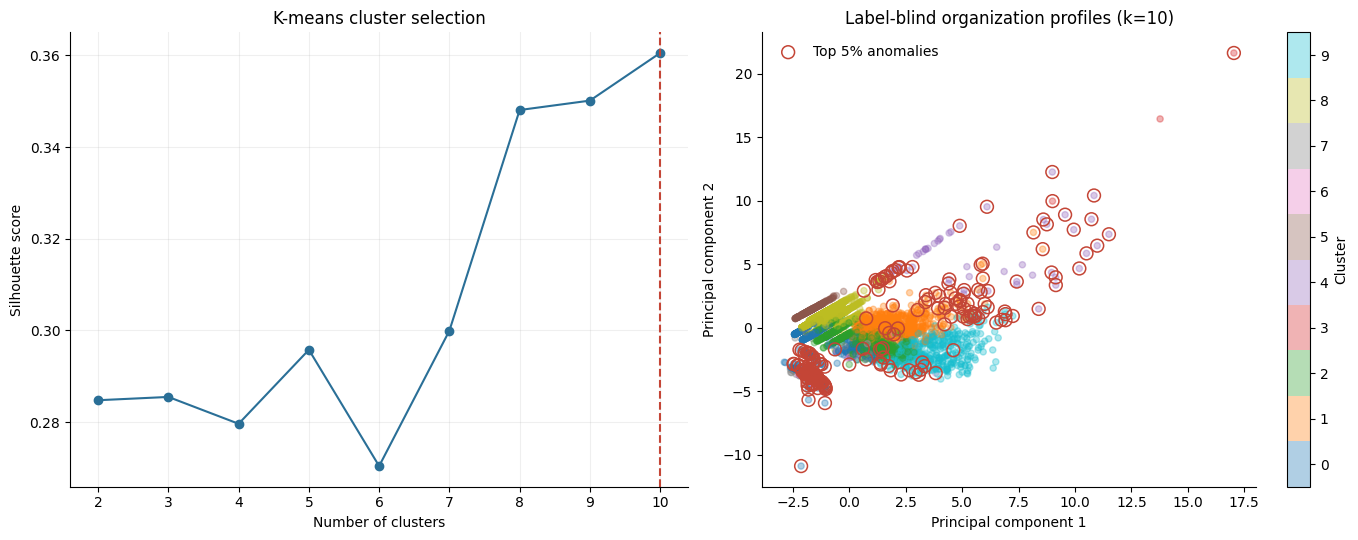

Selected k=10 with silhouette score 0.361


,organizations,anomalies,median_log_received,median_log_granted,median_global_pagerank
cluster,,,,,
0,599,104,9.904,0.000,2.07e-06
1,641,35,15.011,14.249,2.79e-06
2,748,2,13.422,0.000,2.31e-06
3,3,2,21.009,23.431,2.03e-05
4,52,32,19.754,14.795,4.50e-05
5,184,0,12.947,0.000,2.25e-06
6,44,8,10.777,12.905,2.12e-06
7,19,1,10.127,12.214,2.07e-06
8,"1,757",12,11.927,0.000,2.12e-06



Blind anomaly threshold: top 5% by centroid distance
Anomalies selected: 222 of 4,421
OpenSecrets prevalence in full pool: 265/4,421 (6.0%)
OpenSecrets matches among anomalies: 16/222 (7.2%)
Recall of OpenSecrets labels: 6.0%
OpenSecrets enrichment among anomalies: 1.20x


,cluster,ein,name,anomaly_distance,in_opensecrets
0,0,850784793,Marble Freedom Trust,56.874,False
1,1,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,20.436,False
2,0,943147856,SANDLER FOUNDATION,18.891,False
3,0,873323607,CATALYST4 INC,18.770,False
4,3,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,16.808,False
5,1,237825575,NATIONAL PHILANTHROPIC TRUST,16.677,False
6,3,810739440,AMERICAN ONLINE GIVING FOUNDATION INC,15.904,False
7,4,581493949,NATL CHRISTIAN CHARITABLE FDN INC,15.876,False
8,4,530196605,American National Red Cross & Its Constituent Chapters and Branches,14.843,False
9,0,873941853,ADVOCACY ACTION FUND INC,13.461,False


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep the clustering label-blind: no seed labels, model scores, PPR proximity,
# or political-neighbor features derived using seed exclusions.
cluster_features = STRUCTB + BEHAVB
cluster_frame = M[["ein", "name"] + cluster_features].copy()
cluster_matrix = StandardScaler().fit_transform(
    cluster_frame[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
)

silhouette_scores = {}
cluster_models = {}
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    labels = model.fit_predict(cluster_matrix)
    silhouette_scores[cluster_count] = silhouette_score(cluster_matrix, labels)
    cluster_models[cluster_count] = model

best_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
best_cluster_model = cluster_models[best_cluster_count]
cluster_labels = best_cluster_model.labels_
cluster_frame["cluster"] = cluster_labels
M["cluster"] = cluster_labels

# Distance from the assigned centroid is the unsupervised anomaly score.
assigned_centroids = best_cluster_model.cluster_centers_[cluster_labels]
cluster_frame["anomaly_distance"] = np.linalg.norm(
    cluster_matrix - assigned_centroids,
    axis=1,
)
ANOMALY_FRACTION = 0.05
anomaly_cutoff = cluster_frame["anomaly_distance"].quantile(1 - ANOMALY_FRACTION)
cluster_frame["is_anomaly"] = cluster_frame["anomaly_distance"] >= anomaly_cutoff

cluster_summary = (
    cluster_frame.groupby("cluster")
    .agg(
        organizations=("ein", "size"),
        anomalies=("is_anomaly", "sum"),
        median_log_received=("log_received", "median"),
        median_log_granted=("log_granted_out", "median"),
        median_global_pagerank=("global_pr", "median"),
    )
)

embedding = PCA(n_components=2).fit_transform(cluster_matrix)
cluster_frame["pc1"] = embedding[:, 0]
cluster_frame["pc2"] = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(
    list(silhouette_scores),
    list(silhouette_scores.values()),
    marker="o",
    color="#2A6F97",
)
axes[0].axvline(best_cluster_count, color="#C44536", linestyle="--", linewidth=1.5)
axes[0].set_title("K-means cluster selection")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(silhouette_scores))
axes[0].grid(alpha=0.2)

cluster_scatter = axes[1].scatter(
    cluster_frame.pc1,
    cluster_frame.pc2,
    c=cluster_frame.cluster,
    cmap="tab10",
    vmin=-0.5,
    vmax=best_cluster_count - 0.5,
    s=20,
    alpha=0.35,
)
anomaly_points = cluster_frame[cluster_frame.is_anomaly]
axes[1].scatter(
    anomaly_points.pc1,
    anomaly_points.pc2,
    facecolors="none",
    edgecolors="#C44536",
    s=85,
    linewidth=1.1,
    label=f"Top {ANOMALY_FRACTION:.0%} anomalies",
)
axes[1].set_title(f"Label-blind organization profiles (k={best_cluster_count})")
axes[1].set_xlabel("Principal component 1")
axes[1].set_ylabel("Principal component 2")
axes[1].legend(frameon=False, loc="best")
fig.colorbar(
    cluster_scatter,
    ax=axes[1],
    ticks=range(best_cluster_count),
    label="Cluster",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

print(
    f"Selected k={best_cluster_count} with silhouette score "
    f"{silhouette_scores[best_cluster_count]:.3f}"
)
display(
    cluster_summary.style.format({
        "organizations": "{:,.0f}",
        "anomalies": "{:,.0f}",
        "median_log_received": "{:.3f}",
        "median_log_granted": "{:.3f}",
        "median_global_pagerank": "{:.2e}",
    })
)

# Freeze the anomaly set before adding the external OpenSecrets label.
blind_anomalies = (
    cluster_frame.loc[
        cluster_frame.is_anomaly,
        ["cluster", "ein", "name", "anomaly_distance"],
    ]
    .sort_values("anomaly_distance", ascending=False)
    .reset_index(drop=True)
)
blind_anomalies["in_opensecrets"] = blind_anomalies["ein"].isin(seed_set)

pool_opensecrets = int(cluster_frame["ein"].isin(seed_set).sum())
anomaly_opensecrets = int(blind_anomalies.in_opensecrets.sum())
pool_rate = pool_opensecrets / len(cluster_frame)
anomaly_rate = anomaly_opensecrets / len(blind_anomalies)
anomaly_recall = anomaly_opensecrets / pool_opensecrets if pool_opensecrets else 0.0
enrichment = anomaly_rate / pool_rate if pool_rate else np.nan

print(f"\nBlind anomaly threshold: top {ANOMALY_FRACTION:.0%} by centroid distance")
print(f"Anomalies selected: {len(blind_anomalies):,} of {len(cluster_frame):,}")
print(f"OpenSecrets prevalence in full pool: {pool_opensecrets:,}/{len(cluster_frame):,} ({pool_rate:.1%})")
print(f"OpenSecrets matches among anomalies: {anomaly_opensecrets:,}/{len(blind_anomalies):,} ({anomaly_rate:.1%})")
print(f"Recall of OpenSecrets labels: {anomaly_recall:.1%}")
print(f"OpenSecrets enrichment among anomalies: {enrichment:.2f}x")

display(
    blind_anomalies.head(25).style.format({
        "anomaly_distance": "{:.3f}",
    })
)

### What the blind check found

Because the clustering never saw the labels, the overlap it finds is a fair test. When we flag the top 5% most unusual organizations by distance from their cluster centre, 31 of the known dark-money groups show up among 222 anomalies. That is 14.0% of the anomalies against 6.0% of the pool, a 2.33x enrichment, but it still catches only about one label in eight.

So it is a real signal, but a rough one. Most of the top anomalies are donor-advised funds, universities, and large charities that are unusual for their cluster but not political. Distance from the centre is useful as a supporting flag, but the supervised model and the direct political links are better for ranking.


## The real test: can it find groups it never saw?

Out-of-fold scoring already keeps the model from memorising its training set, but we can be stricter. Here we remove 40% of the known dark-money groups completely, from both training and the PageRank personalization, and then check whether the model can still rank them above the hard-negative pool. If it can rank organizations it never saw, it has learned a pattern rather than a list.


In [ ]:
# Hold out 40% of known seeds (never trained, never in PPR); can the model still rank them above background?
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

nm_pool = dict(zip(M.ein, M.name))
seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]

def run_split(frac, rs):
    rng = np.random.default_rng(rs)
    hold = rng.choice(seed_i, size=max(1, int(frac * len(seed_i))), replace=False)
    train_seed = np.setdiff1d(seed_i, hold)
    pv = prox([nodes[i] for i in train_seed])                 # PPR proximity from TRAIN seeds only (leak-free)
    Xall = np.column_stack([Xbase, pv])
    train_rows = np.concatenate([train_seed, neg_i])          # held-out seeds excluded from training
    m = GBC().fit(Xall[train_rows], y[train_rows])
    sc = m.predict_proba(Xall)[:, 1]
    ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
    order = ev[np.argsort(-sc[ev])]; rankmap = {n: r for r, n in enumerate(order, 1)}
    rec = {k: float(np.mean([rankmap[i] <= k for i in hold])) for k in (50, 100, 200)}
    return hold, sc, rankmap, roc_auc_score(ye, sc[ev]), average_precision_score(ye, sc[ev]), rec

FRAC = 0.40
res = [run_split(FRAC, rs) for rs in range(5)]
aucs = [r[3] for r in res]; aps = [r[4] for r in res]
r50 = [r[5][50] for r in res]; r100 = [r[5][100] for r in res]; r200 = [r[5][200] for r in res]
ncand = len(neg_i) + int(FRAC * len(seed_i))
print(f"Hold out {int(FRAC*len(seed_i))}/{len(seed_i)} known dark-money orgs, never trained and never in the PPR.")
print(f"Averaged over 5 random splits, held-out orgs vs {len(neg_i):,} hard negatives (pool ~{ncand:,}):")
print(f"  ROC-AUC   {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")
print(f"  PR-AUC    {np.mean(aps):.3f} +/- {np.std(aps):.3f}  (random baseline ~{len(seed_i)*FRAC/ncand:.3f})")
print(f"  recall@50 {np.mean(r50):.2f}   recall@100 {np.mean(r100):.2f}   recall@200 {np.mean(r200):.2f}")

# One split in detail: which unseen dark-money orgs did the model catch vs miss?
hold, sc, rankmap, auc, ap, rec = res[0]
val = (pd.DataFrame({"ein": [nodes[i] for i in hold], "name": [nm_pool.get(nodes[i], nodes[i]) for i in hold],
                     "score": sc[hold], "rank_of_pool": [rankmap[i] for i in hold]})
       .sort_values("score", ascending=False).reset_index(drop=True))
print(f"\nSplit 0 (AUC {auc:.3f}): {len(hold)} unseen dark-money orgs, median score "
      f"{np.median(sc[hold]):.3f} vs negatives {np.median(sc[neg_i]):.3f}:")
display(val)


Hold out 106/265 known dark-money orgs, never trained and never in the PPR.
Averaged over 5 random splits, held-out orgs vs 4,156 hard negatives (pool ~4,262):
  ROC-AUC   0.888 +/- 0.015
  PR-AUC    0.303 +/- 0.021  (random baseline ~0.025)
  recall@50 0.20   recall@100 0.28   recall@200 0.42

Split 0 (AUC 0.879): 106 unseen dark-money orgs, median score 0.118 vs negatives 0.004:


,ein,name,score,rank_of_pool
0,463501403,COLORADANS FOR RESPONSIBLE ENERGY DEVELOPMENT,0.964660,1
1,521009116,NATIONAL TAXPAYERS UNION,0.898504,2
2,822007387,NATIONAL SECURITY ACTION,0.811975,3
3,201597444,TRUMAN NATIONAL SECURITY PROJECT,0.809494,4
4,742556532,NATIONAL WILDLIFE FEDERATION ACTION FUND,0.806301,5
...,...,...,...,...
101,550306990,WEST VIRGINIA CHAMBER OF COMMERCE,0.003498,2377
102,824482629,CAMPAIGN FOR SUSTAINABLE RX PRICING,0.003498,2505
103,521271179,BUSINESS EXECUTIVES FOR NATIONAL SECURITY,0.003131,2803
104,814571869,Womens March Inc,0.002523,3968


## Does the political-neighbour feature help?

Some of our earlier misses were trade groups such as credit-union leagues, chambers, and realtor associations. They do not show the usual conduit money pattern, but they keep clearly political company. The political-neighbour feature is meant to catch that. It measures how much of an organization's grant network is (c)(4)s, (c)(6)s, and 527s, with the labels themselves removed. To see whether it helps, we run the model with and without it, on both out-of-fold and held-out evaluation.


In [ ]:
# Ablation: model WITHOUT political-neighbor (structural+behaviour) vs WITH it (Xbase, the full model).
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

Xno = M[STRUCTB + BEHAVB].fillna(0).values          # full model minus the political-neighbor block
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"{'feature set':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("PPR + base", Xno), ("PPR + base + political-neighbor", Xbase)]:
    o = _oof(Xb)
    print(f"{tag:34s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs, recs = [], []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
        order = ev[np.argsort(-sc[ev])]; rk = {n: r for r, n in enumerate(order, 1)}
        recs.append(np.mean([rk[i] <= 200 for i in hold]))
    return np.mean(aucs), np.std(aucs), np.mean(recs)
print()
for tag, Xb in [("base", Xno), ("+ political-neighbor", Xbase)]:
    a, s, r = _holdout(Xb)
    print(f"held-out  {tag:22s} ROC-AUC {a:.3f} ± {s:.3f}   recall@200 {r:.2f}")


feature set                        OOF ROC-AUC OOF PR-AUC
PPR + base                               0.871      0.271
PPR + base + political-neighbor          0.887      0.382

held-out  base                   ROC-AUC 0.879 ± 0.021   recall@200 0.38
held-out  + political-neighbor   ROC-AUC 0.888 ± 0.015   recall@200 0.42


## What the lobbying records add

Using the crosswalk, we attach to each candidate how many filings, distinct bills, and issue areas it is tied to. Two questions follow. Does that lobbying footprint improve the model, and does it back up the organizations already near the top of our list? We test it as features, then read it back as corroboration on the leads.


In [ ]:
# Bridge pool EINs -> LDA lobbying record via high_conf_matches; test as features + show as corroboration.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

conn.register("pool_eins", pd.DataFrame({"ein": nodes}))
lda = q("""
WITH pool AS (SELECT DISTINCT ein FROM pool_eins),
     ein_lda AS (SELECT DISTINCT ein, lda_key FROM high_conf_matches WHERE role = 'client'),
     cf AS (SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
            FROM lda_filings WHERE json_valid(raw_json)),
     agg AS (
        SELECT el.ein,
               COUNT(DISTINCT cf.filing_uuid) AS lda_n_filings,
               COUNT(DISTINCT (bl.bill_type, bl.bill_number)) AS lda_n_bills,
               COUNT(DISTINCT act.general_issue_code) AS lda_n_issues
        FROM ein_lda el JOIN cf USING (lda_key)
        LEFT JOIN lobbying_bill_links bl USING (filing_uuid)
        LEFT JOIN lda_lobbying_activities act USING (filing_uuid)
        GROUP BY el.ein)
SELECT p.ein,
       COALESCE(agg.lda_n_filings, 0) AS lda_n_filings,
       COALESCE(agg.lda_n_bills, 0)   AS lda_n_bills,
       COALESCE(agg.lda_n_issues, 0)  AS lda_n_issues,
       CASE WHEN agg.ein IS NOT NULL THEN 1 ELSE 0 END AS is_lda_client
FROM pool p LEFT JOIN agg USING (ein)
""")
Mlda = M.merge(lda, on="ein", how="left")
for c in ["lda_n_filings", "lda_n_bills", "lda_n_issues", "is_lda_client"]:
    Mlda[c] = Mlda[c].fillna(0)
Mlda["log_lda_bills"] = np.log1p(Mlda.lda_n_bills)
LDAF = ["is_lda_client", "log_lda_bills", "lda_n_issues"]

cov_pool = int((Mlda.is_lda_client == 1).sum())
cov_seed = int(((Mlda.is_lda_client == 1) & (y == 1)).sum())
print(f"LDA lobbying coverage in the pool: {cov_pool}/{len(nodes)} orgs are matched LDA clients "
      f"({cov_seed}/{int(y.sum())} seeds).")

Xlda = np.column_stack([Xbase, Mlda[LDAF].fillna(0).values])
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':28s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    o = _oof(Xb)
    print(f"{tag:28s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:26s} ROC-AUC {a:.3f} ± {s:.3f}")

# Practical use: LDA lobbying as corroboration on the current leads.
print("\nTop 15 leads with LDA lobbying corroboration:")
display(leads.head(15).merge(Mlda[["ein", "is_lda_client", "lda_n_bills", "lda_n_issues"]], on="ein", how="left")
        [["ein", "name", "score", "is_lda_client", "lda_n_bills", "lda_n_issues"]])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

LDA lobbying coverage in the pool: 250/4421 orgs are matched LDA clients (49/265 seeds).

feature set                  OOF ROC-AUC OOF PR-AUC
full model                         0.887      0.382
full model + LDA lobbying          0.891      0.375

held-out  full model                 ROC-AUC 0.888 ± 0.015
held-out  full model + LDA lobbying  ROC-AUC 0.891 ± 0.015

Top 15 leads with LDA lobbying corroboration:


,ein,name,score,is_lda_client,lda_n_bills,lda_n_issues
0,391142477,WISCONSIN LABORERS' DISTRICT COUNCIL,0.856983,0,0,0
1,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.840749,0,0,0
2,530167933,THE WILDERNESS SOCIETY,0.831783,1,1,1
3,270637437,BOLD ALLIANCE INC,0.830964,0,0,0
4,934932914,Defend Washington,0.788846,0,0,0
5,742736849,TEXAS FREEDOM NETWORK,0.736980,0,0,0
6,520941402,THE ROAD INFORMATION PROGRAM INC,0.731327,0,0,0
7,861965600,BLACK MEN VOTE CIVIC ACTION FUND,0.688065,0,0,0
8,923566420,Smarter Regulation,0.673797,0,0,0
9,834660479,RURAL ARIZONA ACTION,0.653091,0,0,0


## Following the same names into election spending

FEC filings do not include EINs, so linking a Super PAC to an IRS organization means matching on names and location. We take the independent-expenditure-only committees, normalise the names, and match. Exact hits come first, then near matches with a blocked Jaro-Winkler score of at least 0.85, and we require the states to agree and the final similarity to clear 0.90 before trusting a link.

This is deliberately imperfect. Two similar names in the same state can be different organizations, so treat these as leads to check, not confirmed facts. When a link does hold, it shows a familiar name turning up in election spending. We limit the totals to the election cycle that matches our IRS years.


In [ ]:
# FEC Super PAC linkage: exact and near-name matching with committee-state agreement.
import re
import numpy as np, pandas as pd

for _t in ("committees", "fec_disbursements"):
    conn.execute(f"""CREATE OR REPLACE VIEW {_t} AS
        SELECT * FROM read_parquet('{(ROOT / 'parquet_export' / _t / '*.parquet').as_posix()}', union_by_name=true)""")

# FEC totals use two-year election cycles. Map each selected IRS year to its
# corresponding cycle ending year (for example, 2023 and 2024 both map to 2024).
ANALYSIS_YEARS = tuple(sorted({int(year) for year in re.findall(r"\d{4}", YEARS)}))
FEC_CYCLES = tuple(sorted({year if year % 2 == 0 else year + 1 for year in ANALYSIS_YEARS}))
FEC_CYCLES_SQL = "(" + ", ".join(map(str, FEC_CYCLES)) + ")"
print(f"IRS analysis years: {ANALYSIS_YEARS}; corresponding FEC cycles: {FEC_CYCLES}")

# Type O is an independent-expenditure-only committee. The totals extract exposes
# committee_state in raw_json; ZIP is unavailable.
conn.execute("""
CREATE OR REPLACE TEMP TABLE fec_committees AS
SELECT committee_id,
       any_value(name) AS committee_name,
       norm_org(any_value(name)) AS normalized_name,
       any_value(committee_type) AS committee_type,
       any_value(party) AS party,
       max(UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.committee_state')), ''))) AS fec_state,
       NULL::VARCHAR AS fec_zip
FROM committees
WHERE name IS NOT NULL
  AND committee_type = 'O'
  AND json_valid(raw_json)
GROUP BY committee_id
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE fec_matches AS
WITH exact AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           irs.ein, irs.irs_name, 1.0 AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           FALSE AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs USING (normalized_name)
),
near AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           irs.ein, irs.irs_name,
           jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           FALSE AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs
      ON {name_block_on('fc.normalized_name', 'irs.normalized_name')}
     AND fc.normalized_name <> irs.normalized_name
    WHERE jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) >= {NEAR_NAME_MIN_SIMILARITY}
)
SELECT * FROM exact UNION ALL SELECT * FROM near
""")

# Cycle totals are filtered to the election cycles that overlap the selected IRS years.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE fec_spend AS
SELECT committee_id,
       TRY_CAST(disbursement_date AS INTEGER) AS cycle,
       SUM(TRY_CAST(disbursement_amount AS DOUBLE)) AS disbursements,
       SUM(TRY_CAST(regexp_extract(disbursement_description, 'independent_expenditures=([0-9.]+)', 1) AS DOUBLE)) AS ie
FROM fec_disbursements
WHERE recipient_name = '__CYCLE_TOTALS__'
  AND TRY_CAST(disbursement_date AS INTEGER) IN {FEC_CYCLES_SQL}
GROUP BY committee_id, cycle
""")

fec_link = q(f"""
WITH ranked AS (
    SELECT m.*, {tier_case('name')} AS tier,
           ROW_NUMBER() OVER (PARTITION BY m.committee_id
                              ORDER BY state_agrees DESC, name_similarity DESC, ein) AS rn
    FROM fec_matches m
    WHERE name_similarity >= {HIGH_CONF_MIN} AND state_agrees
)
SELECT r.ein, r.irs_name, r.committee_id, r.committee_name, r.committee_type, r.party,
       ROUND(r.name_similarity, 4) AS name_similarity, r.tier, s.cycle,
       COALESCE(s.ie, 0) AS ie, COALESCE(s.disbursements, 0) AS disb
FROM ranked r
JOIN fec_spend s USING (committee_id)
WHERE r.rn = 1
""")
print(f"FEC Super PACs linked to IRS EINs for cycles {FEC_CYCLES} "
      f"(sim>={HIGH_CONF_MIN}, state agrees): "
      f"{fec_link.committee_id.nunique():,} committees -> {fec_link.ein.nunique():,} EINs")
print(fec_link.groupby(["cycle", "tier"]).size().to_string())

# Current labels and screened leads with a matched Super PAC, reported by cycle.
lead_eins = set(filtered_leads.head(50).ein)
dm = fec_link[fec_link.ein.isin(seed_set) | fec_link.ein.isin(lead_eins)].copy()
dm["cohort"] = np.where(dm.ein.isin(seed_set), "label", "screened lead")
dm["org"] = dm.ein.map(nm)
print("\nLabeled organizations and screened leads with a matched FEC Super PAC:")
display(dm.sort_values(["cycle", "ie"], ascending=[False, False])
        [["cycle", "org", "cohort", "committee_name", "committee_type", "party", "name_similarity", "tier", "ie", "disb"]].head(25))

IRS analysis years: (2023, 2024); corresponding FEC cycles: (2024,)
FEC Super PACs linked to IRS EINs for cycles (2024,) (sim>=0.9, state agrees): 396 committees -> 374 EINs
cycle  tier        
2024   name + state    396

Labeled organizations and screened leads with a matched FEC Super PAC:


,cycle,org,cohort,committee_name,committee_type,party,name_similarity,tier,ie,disb
67,2024,American Principles Project,label,AMERICAN PRINCIPLES PROJECT PAC,O,None,1.0000,name + state,7933282.25,12862572.49
141,2024,A BETTER WISCONSIN TOGETHER INC,screened lead,A BETTER WISCONSIN TOGETHER ACTION,O,None,0.9563,name + state,5083561.49,5336103.94
337,2024,Black Voters Matter Fund Inc,label,BLACK VOTERS MATTER ACTION PAC,O,None,0.9365,name + state,3623633.16,4310873.87
339,2024,WORKER POWER,label,WORKER POWER PAC,O,None,1.0000,name + state,2804390.03,10028516.68
19,2024,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA,screened lead,LABORERS' INTERNATIONAL UNION OF NORTH AMERICA...,O,None,0.9615,name + state,2786934.92,9892650.00
240,2024,REPRODUCTIVE FREEDOM FOR ALL,label,REPRODUCTIVE FREEDOM FOR ALL FREEDOM FUND,O,None,0.9500,name + state,2638037.61,2915627.98
357,2024,In Union USA Action,label,IN UNION USA,O,None,0.9263,name + state,2061874.95,7483307.49
48,2024,CASA IN ACTION INC,label,CASA IN ACTION PAC,O,None,1.0000,name + state,1748702.01,3859637.08
367,2024,MONTANA HUNTERS AND ANGLERS ACTION,label,MONTANA HUNTERS AND ANGLERS LEADERSHIP FUND,O,None,0.9263,name + state,1063619.18,1284527.31
165,2024,WORKER POWER,label,WORKER POWER PAC FOR GEORGIA,O,None,0.9200,name + state,1030000.00,1030000.00


In [ ]:
# FEC as a modeling signal (has_fec + log independent expenditures / disbursements) + corroboration on leads.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

fec_by_ein = (fec_link.groupby("ein")
              .agg(fec_n_committees=("committee_id", "nunique"),
                   fec_ie=("ie", "sum"), fec_disb=("disb", "sum")).reset_index())
fe = pd.DataFrame({"ein": nodes}).merge(fec_by_ein, on="ein", how="left").fillna(0)
fe["has_fec"] = (fe.fec_n_committees > 0).astype(int)
fe["log_fec_ie"] = np.log1p(fe.fec_ie); fe["log_fec_disb"] = np.log1p(fe.fec_disb)
FECF = ["has_fec", "log_fec_ie", "log_fec_disb"]
Xfec = np.column_stack([Xbase, fe[FECF].values])

cov_pool = int(fe.has_fec.sum()); cov_seed = int(((fe.has_fec == 1).values & (y == 1)).sum())
print(f"FEC committee coverage in the pool: {cov_pool}/{len(nodes)} orgs run a linked Super PAC "
      f"({cov_seed}/{int(y.sum())} seeds).")

cv = StratifiedKFold(5, shuffle=True, random_state=42)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':24s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    o = _oof(Xb)
    print(f"{tag:24s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:20s} ROC-AUC {a:.3f} ± {s:.3f}")

print("\nTop 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):")
display(leads.head(15).merge(fe[["ein", "has_fec", "fec_ie", "fec_disb"]], on="ein", how="left")
        [["ein", "name", "score", "has_fec", "fec_ie", "fec_disb"]])


FEC committee coverage in the pool: 69/4421 orgs run a linked Super PAC (27/265 seeds).

feature set              OOF ROC-AUC OOF PR-AUC
full model                     0.887      0.382
full model + FEC               0.885      0.360

held-out  full model           ROC-AUC 0.888 ± 0.015
held-out  full model + FEC     ROC-AUC 0.888 ± 0.015

Top 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):


,ein,name,score,has_fec,fec_ie,fec_disb
0,391142477,WISCONSIN LABORERS' DISTRICT COUNCIL,0.856983,0,0.00,0.00
1,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.840749,0,0.00,0.00
2,530167933,THE WILDERNESS SOCIETY,0.831783,0,0.00,0.00
3,270637437,BOLD ALLIANCE INC,0.830964,0,0.00,0.00
4,934932914,Defend Washington,0.788846,0,0.00,0.00
5,742736849,TEXAS FREEDOM NETWORK,0.736980,0,0.00,0.00
6,520941402,THE ROAD INFORMATION PROGRAM INC,0.731327,0,0.00,0.00
7,861965600,BLACK MEN VOTE CIVIC ACTION FUND,0.688065,0,0.00,0.00
8,923566420,Smarter Regulation,0.673797,0,0.00,0.00
9,834660479,RURAL ARIZONA ACTION,0.653091,0,0.00,0.00


## Takeaways and next steps

What we found:

- The known dark-money groups sit in a distinct part of the 2023-2024 grant network, and the model learns that pattern instead of just memorising the list. It still ranks held-out groups well above the hard-negative background.
- No single signal does the work. Tax status is a strong prior (heavy on (c)(4) and 527, light on (c)(3)), pass-through money movement adds the behaviour, and closeness to other seeds adds the network view. Together they separate real conduits from large but apolitical institutions.
- A simple two-signal screen after scoring removes most institutional false positives without losing the real labels.
- The outside checks agree. Lobbying records, FEC Super PAC links, and low transparency scores tend to land on the same organizations the model already ranks high. That kind of independent agreement is what builds confidence.

How to use it:

- Treat `filtered_leads` as a review queue, not an answer. Work down it by score, and use the interactive graphs and the lobbying and FEC matches to decide which names are worth a closer look.
- The leads the model likes but the screen drops, or that have no outside support, are where a person should spend time first.
- To refresh, update the OpenSecrets label file and the yearly parquet data, then run the notebook top to bottom. Changing `YEARS` points the whole pipeline at a different cycle.
- Possible extensions: add more label sources to widen the seed set, add shared board members or officers as another link between organizations, or track how a lead's score changes from one year to the next.

One caveat to keep in mind: every score here is a lead, not a conclusion. The point of the pipeline is to narrow tens of thousands of organizations down to a short list worth investigating. The final call still belongs to a person reading the filings.
